# System-of-Systems Turbine Model

This notebook simulates the Pelton turbine model, compares monolithic and modular time integration, and demonstrates the multi-module estimation workflow used in the paper examples.



MONOLITHIC PELTON — Heun (RK2) Fixed-Step Integrator
dt = 0.0005, steps = 300000
Torsional fn = 3.848 Hz
ANALYSIS SUMMARY

Final speed: 378.13 rpm
Mean q     : 1.043 (normalized)

Generator vibration (steady state):
  RMS radius : 214.90 μm
  Max radius : 218.97 μm (5.5% of clearance)

Runner vibration (steady state):
  RMS radius : 55.69 μm
  Max radius : 58.94 μm (1.7% of clearance)

Torsional dynamics:
  α peak–peak : 5.4889 mrad
  β peak–peak : 132.6997 mrad/s
  f_torsion   : 3.848 Hz
Running modular Jacobi+Heun with dt_mod = 0.002 ...

ERROR SUMMARY: Modular (Jacobi+Heun)  −  Monolithic (Heun)
Global max ||Δx||₂ over time: 8.2567e-02
Final-time   ||Δx(t_end)||₂  : 5.3701e-02

State  0: max|Δx_i(t)| = 2.8478e-05, |Δx_i(t_end)| = 2.7400e-06
State  1: max|Δx_i(t)| = 3.1794e-05, |Δx_i(t_end)| = 1.1274e-06
State  2: max|Δx_i(t)| = 1.5748e-04, |Δx_i(t_end)| = 1.0959e-05
State  3: max|Δx_i(t)| = 4.6093e-04, |Δx_i(t_end)| = 5.7411e-06
State  4: max|Δx_i(t)| = 3.3625e-04, |Δx_i(t_end)| = 

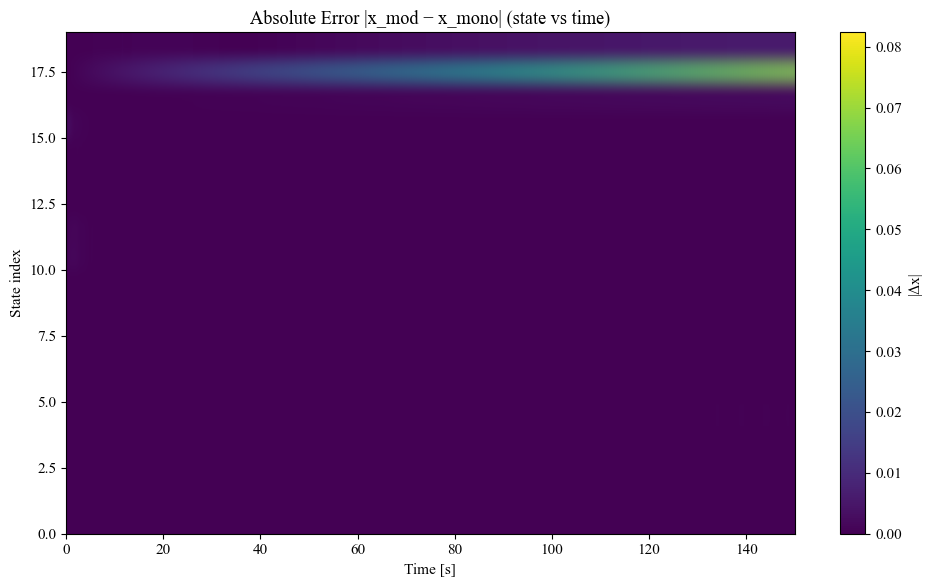

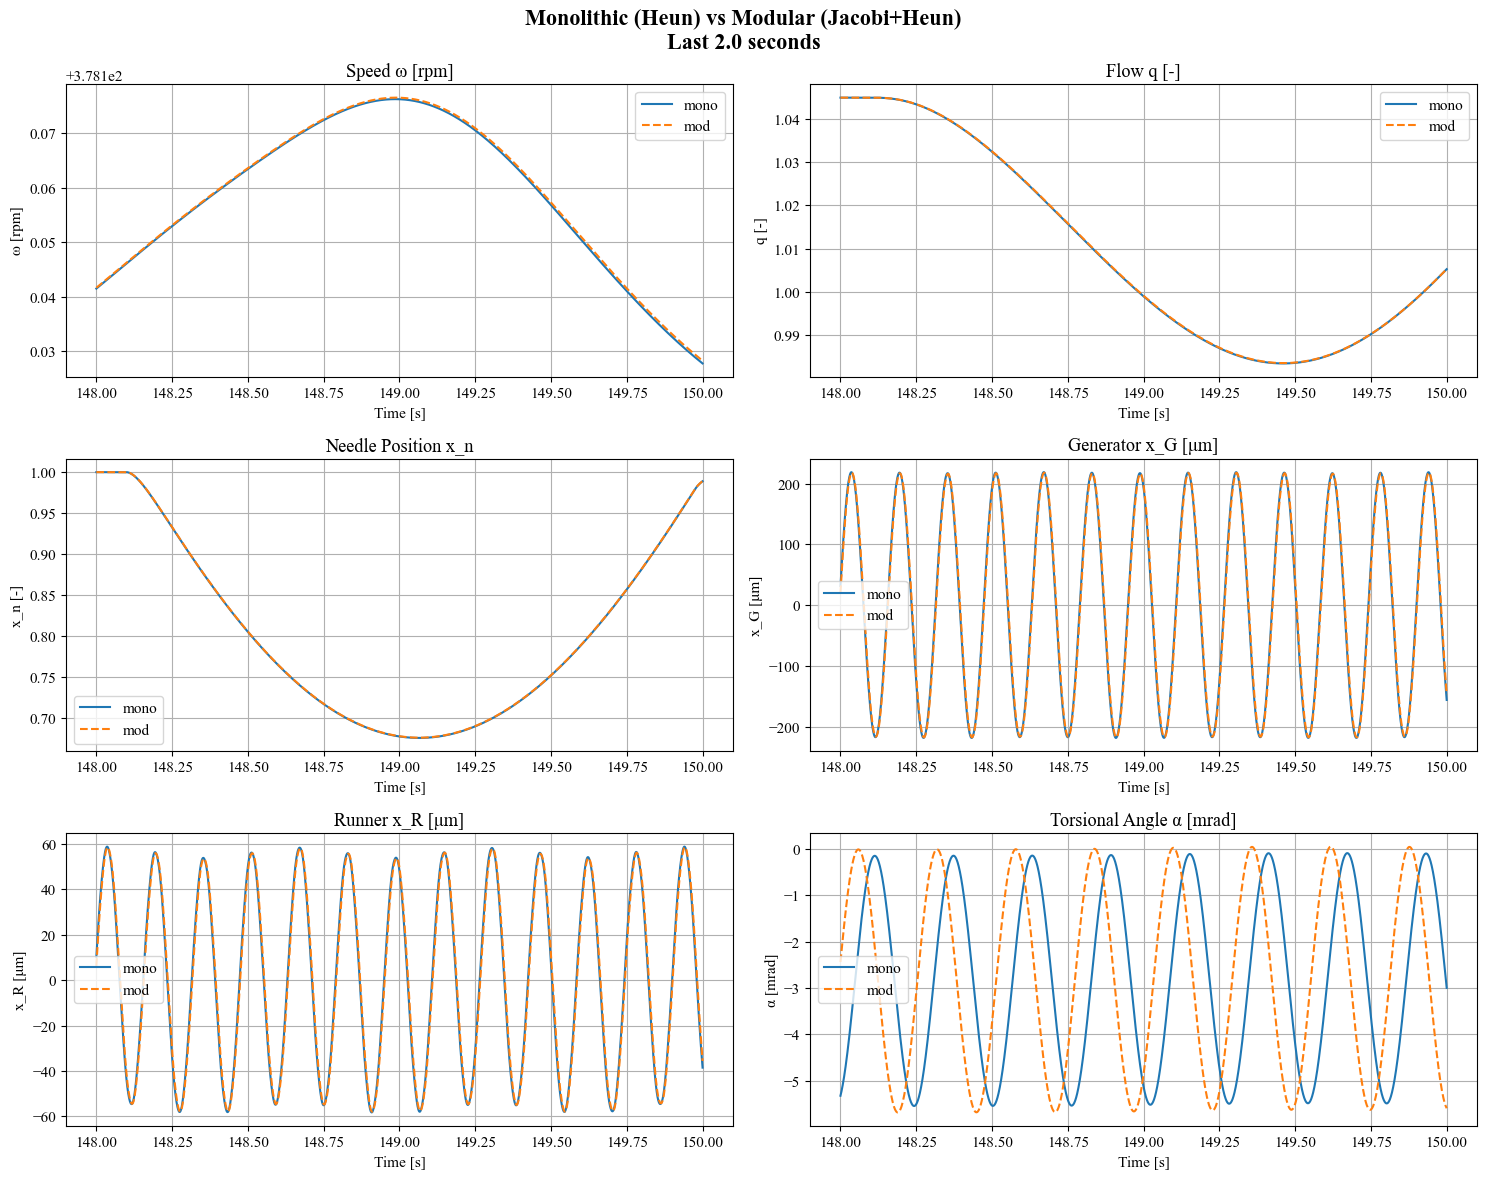

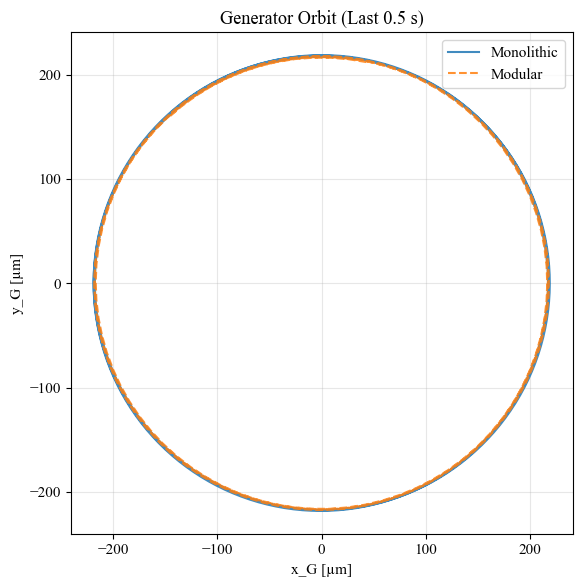

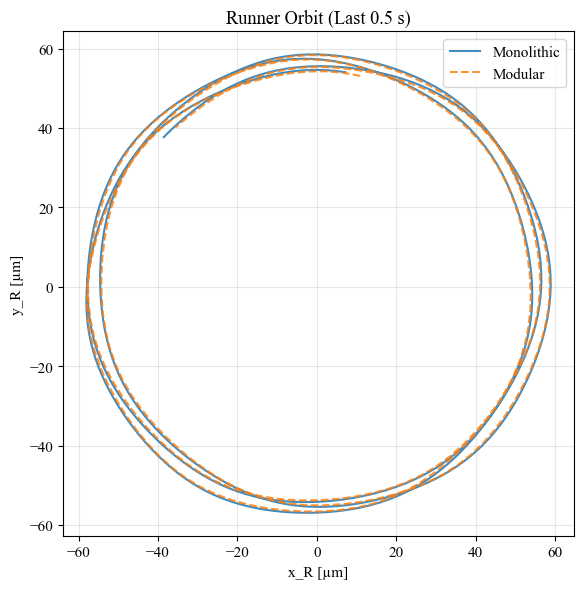

In [9]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, Tuple
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)


# ======================================================================
# PARAMETERS
# ======================================================================

@dataclass
class Parameters:
    """
    Hybrid Pelton model parameters (Xu 2017 + Shi 2022).
    Units are physical (SI) for vibration / torsion,
    and per-unit for hydraulic / governor loop.
    """

    # --- Basic machine data ---
    n_rated: float = 375.0          # rpm
    Q_rated: float = 27.0           # m^3/s
    H_rated: float = 595.0          # m
    eta: float = 0.92
    Z_n: int = 6                    # number of nozzles/buckets
    rho: float = 1000.0             # kg/m^3
    g: float = 9.81                 # m/s^2

    # --- Hydraulic / penstock model (Xu) ---
    T_e: float = 0.5155             # elastic time constant [s]
    phi_j: float = 0.985
    s_e: float = 0.102              # max needle stroke [m]
    h0: float = 1.0                 # upstream head coefficient
    y_r: float = 0.9                # guide vane opening
    T_q: float = 0.5                # flow inertia time constant [s]

    # --- Governor PID (Xu, tuned) ---
    k_p: float = 5.0                # NOT 5.0
    k_i: float = 2.12
    k_d: float = 10.0
    T_y: float = 0.04               # needle servo time constant [s]

    # --- Masses and inertias (Shi) ---
    m1: float = 6e5                 # generator mass [kg]
    m2: float = 3e5                 # runner mass [kg]
    J1: float = 6.8e6               # generator inertia [kg·m^2]
    J2: float = 3.4e6               # runner inertia [kg·m^2]

    # --- Eccentricities & shaft geometry (Shi) ---
    e1: float = 0.5e-3              # generator eccentricity [m]
    e2: float = 0.5e-3              # runner eccentricity [m]
    E: float = 200e9                # Young’s modulus [Pa]
    G: float = 80e9                 # shear modulus [Pa]
    l_shaft: float = 10.3           # distance between masses [m]
    d_H: float = 1.15               # shaft outer diameter [m]
    d_B: float = 0.3                # shaft inner diameter [m]
    h_shaft: float = 11.995         # overall shaft length [m]
    phi_m: float = 0.01             # misalignment angle [rad]

    # shaft segments (for lateral stiffness matrix, approx Xu 2017)
    a: float = 1.5                  # G–nearest bearing distance [m]
    b: float = 7.3                  # bearing span [m]
    c: float = 1.5                  # R–nearest bearing distance [m]
    d: float = 1.0                  # R–free end distance [m]

    # --- Lateral stiffness & damping (bearings etc.) ---
    k_gen: float = 2e9              # generator bearing stiffness [N/m]
    k_run: float = 8e9              # runner bearing stiffness [N/m]
    k_cross: float = 2e7            # cross-coupling stiffness [N/m]

    c_gen: float = 1e6              # generator damping [N·s/m]
    c_run: float = 1e6              # runner damping [N·s/m]
    c_cross: float = 2e4            # cross-coupling damping [N·s/m]

    # --- Torsional & rotational damping ---
    c_t: float = 1e3                # torsional damping [N·m·s/rad]
    D_omega: float = 1e5            # rotational damping about sync [N·m·s/rad]
    T_ab: float = 10.0              # mechanical time constant (Xu) – used only for scaling

    # --- Clearances, rubbing, seal ---
    delta_0: float = 4e-3           # generator air gap [m]
    delta_2: float = 3.5e-3         # runner seal clearance [m] (corrected)
    k_r: float = 6e9                # rubbing stiffness [N/m]
    f_fric: float = 0.02            # friction factor

    K_seal: float = 3e7             # seal stiffness [N/m]
    D_seal: float = 1e5             # seal damping [N·s/m]
    tau_seal: float = 0.3           # circumferential velocity ratio

    # --- Xu torque coefficients (Eq. 18/19) ---
    e_x: float = 1.0                # torque vs speed deviation n
    e_y: float = 0.5                # torque vs flow deviation (q-1)
    e_h: float = 1.5                # torque vs head deviation h

    # --- Hydraulic excitations (Shi) ---
    A_vortex: float = 2e4           # vortex excitation amplitude [N]
    f_vortex_ratio: float = 0.25    # vortex frequency ratio (0.25× synchronous)

    # --- Derived quantities (filled in __post_init__) ---
    omega_rated: float = field(init=False)
    P_rated: float = field(init=False)
    M_gB: float = field(init=False)

    k_y: float = field(init=False)      # torsional stiffness
    J1_eff: float = field(init=False)
    J2_eff: float = field(init=False)
    J_tot: float = field(init=False)
    J_eq: float = field(init=False)     # reduced torsional inertia

    m_01: float = field(init=False)
    m_02: float = field(init=False)
    C_q: float = field(init=False)

    K11: float = field(init=False)     # shaft lateral stiffness coupling
    K22: float = field(init=False)
    K12: float = field(init=False)

    def __post_init__(self):
        # rated speed (rad/s) & power/torque
        self.omega_rated = 2 * np.pi * self.n_rated / 60.0
        self.P_rated = self.rho * self.g * self.Q_rated * self.H_rated * self.eta
        self.M_gB = self.P_rated / self.omega_rated

        # torsional stiffness k_y = G J_p / L
        J_p = np.pi / 32.0 * (self.d_H**4 - self.d_B**4)
        self.k_y = self.G * J_p / self.l_shaft

        # effective inertias including eccentricity/misalignment (Shi)
        self.J1_eff = self.J1 + 2 * self.m1 * self.e1**2
        self.J2_eff = self.J2 + 2 * self.m2 * (
            self.e2 * np.cos(self.phi_m) + self.h_shaft * np.sin(self.phi_m)
        )**2

        self.J_tot = self.J1_eff + self.J2_eff
        self.J_eq = (self.J1_eff * self.J2_eff) / (self.J1_eff + self.J2_eff)

        # nozzle geometry (Xu)
        alpha_n = np.radians(45.0)
        beta_n = np.radians(62.0)
        self.m_01 = np.pi * np.tan(alpha_n / 2.0) * 0.218 * np.cos((alpha_n + beta_n) / 4.0)
        self.m_02 = np.pi * np.tan(alpha_n / 2.0) ** 2 * np.cos((alpha_n + beta_n) / 4.0)

        # scaling C_q so that q ≈ 1 at x_n = 0.8, h = 0
        x_eq = 0.8
        A_eq = (
            self.m_01 * self.s_e * (x_eq + 1.0)
            - self.m_02 * self.s_e**2 * (x_eq + 1.0) ** 2
        )
        self.C_q = 1.0 / (A_eq * np.sqrt(2 * self.g * self.H_rated))

        # lateral shaft stiffness (Xu 2017 form, approximate)
        I = np.pi / 64.0 * (self.d_H**4 - self.d_B**4)
        k_s_B = 3 * self.E * I / self.b**3  # base stiffness for length b

        k_G = k_s_B * (self.a**2 + self.b**2 + 3 * self.a * self.b) / (3 * self.a * self.b)
        k_R = k_s_B * (self.c**2 + self.b**2 + 3 * self.c * self.b) / (3 * self.c * self.b)
        k_coupling = -k_s_B * (self.a + self.b) * (self.b + self.c) / (3 * self.a * self.b)

        self.K11 = 4 * k_G
        self.K22 = 4 * k_R
        self.K12 = 4 * k_coupling


# ======================================================================
# MONOLITHIC DYNAMICS
# ======================================================================

def pelton_ode(t: float, x: np.ndarray, p: Parameters) -> np.ndarray:
    """
    19-state Pelton turbine model with:
      • hydraulic + governor (Xu style, normalized)
      • linearized torque model (Xu Eq. 18–19)
      • coupled generator/runner lateral vibrations (Shi)
      • torsional mode + lateral–torsional coupling
    """

    dx = np.zeros(19)

    # unpack states
    x1, x2, x3, q = x[0], x[1], x[2], x[3]
    x_n, x_gov = x[4], x[5]
    n_state, omega = x[6], x[7]

    xG, yG, vxG, vyG = x[8], x[9], x[10], x[11]
    xR, yR, vxR, vyR = x[12], x[13], x[14], x[15]

    alpha_t, beta_t = x[16], x[17]
    phi1 = x[18]

    h = x3                     # head deviation (per-unit)
    phi2 = phi1 - alpha_t      # runner angle
    n = n_state                # speed deviation (per-unit)

    x_n_eff = np.clip(x_n, 0.0, 1.0)

    # --------------------------------------------------
    # (1) HYDRAULICS (x1,x2,x3,q)  – Xu elastic penstock + nozzle
    # --------------------------------------------------
    dx[0] = x2
    dx[1] = x3

    dx[2] = (
        -np.pi**2 / p.T_e**2 * x2
        + 1.0 / (p.Z_n * p.T_e**3) * (p.h0 - x3 / p.y_r**2 - q**2)
    )

    A_n = max(
        p.m_01 * p.s_e * (x_n_eff + 1.0)
        - p.m_02 * p.s_e**2 * (x_n_eff + 1.0) ** 2,
        1e-8,
    )

    q_target = p.C_q * A_n * np.sqrt(2 * p.g * p.H_rated * max(h + 1.0, 0.1))
    dx[3] = (q_target - q) / p.T_q

    # --------------------------------------------------
    # (2) TORQUES & ROTATIONAL DOF (ω, n, φ1) – Xu torque model
    # --------------------------------------------------
    m_t = p.e_x * n + p.e_y * (q - 1.0) + p.e_h * h
    M_t = p.M_gB * (1.0 + m_t)
    M_g = p.M_gB * (omega / p.omega_rated)

    omega_err = omega - p.omega_rated
    M_damp = p.D_omega * omega_err

    omega_dot = (M_t - M_g - M_damp) / p.J_tot
    dx[7] = omega_dot
    dx[6] = omega_dot / p.omega_rated
    dx[18] = omega

    # --------------------------------------------------
    # (3) GOVERNOR (x_n, x_gov)
    # --------------------------------------------------
    s_cmd = governor_command(t)
    error = s_cmd - n

    dx[5] = error
    n_dot = dx[6]

    u_pid = p.k_p * error + p.k_i * x_gov - p.k_d * n_dot
    u_des = np.clip(u_pid, 0.0, 1.0)
    dx[4] = (u_des - x_n) / p.T_y

    # --------------------------------------------------
    # (4) GENERATOR LATERAL DOF (xG,yG)
    # --------------------------------------------------
    rG = np.sqrt(xG**2 + yG**2) + 1e-12

    Fx_kG = -p.k_gen * xG - p.K11 * xG - p.K12 * xR
    Fy_kG = -p.k_gen * yG - p.K11 * yG - p.K12 * yR

    Fx_kcG = -p.k_cross * yG
    Fy_kcG =  p.k_cross * xG

    Fx_cG = -p.c_gen * vxG
    Fy_cG = -p.c_gen * vyG
    Fx_ccG = -p.c_cross * vyG
    Fy_ccG =  p.c_cross * vxG

    Fx_unbG = p.m1 * p.e1 * omega**2 * np.cos(phi1)
    Fy_unbG = p.m1 * p.e1 * omega**2 * np.sin(phi1)

    Fx_rubG = Fy_rubG = 0.0
    if rG > p.delta_0:
        pen = (rG - p.delta_0) * p.k_r / rG
        Fx_rubG = -pen * (xG - p.f_fric * yG)
        Fy_rubG = -pen * (p.f_fric * xG + yG)

    Fx_G = Fx_kG + Fx_kcG + Fx_cG + Fx_ccG + Fx_unbG + Fx_rubG
    Fy_G = Fy_kG + Fy_kcG + Fy_cG + Fy_ccG + Fy_unbG + Fy_rubG

    dx[8] = vxG
    dx[9] = vyG
    dvxG = Fx_G / p.m1
    dvyG = Fy_G / p.m1
    dx[10] = dvxG
    dx[11] = dvyG

    # --------------------------------------------------
    # (5) RUNNER LATERAL DOF (xR,yR)
    # --------------------------------------------------
    rR = np.sqrt(xR**2 + yR**2) + 1e-12

    Fx_kR = -p.k_run * xR - p.K22 * xR - p.K12 * xG
    Fy_kR = -p.k_run * yR - p.K22 * yR - p.K12 * yG

    Fx_kcR = -0.8 * p.k_cross * yR
    Fy_kcR =  0.8 * p.k_cross * xR

    tau = p.tau_seal
    Fx_seal = -p.K_seal * xR - tau * omega * p.D_seal * yR
    Fy_seal =  tau * omega * p.D_seal * xR - p.K_seal * yR

    Fx_cR = -p.c_run * vxR
    Fy_cR = -p.c_run * vyR

    Fx_unbR = p.m2 * p.e2 * omega**2 * np.cos(phi2)
    Fy_unbR = p.m2 * p.e2 * omega**2 * np.sin(phi2)

    f_vortex = p.f_vortex_ratio * omega
    Fx_hyd = p.A_vortex * q * np.sin(f_vortex * t)
    Fy_hyd = p.A_vortex * q * np.cos(f_vortex * t)

    f_blade = p.Z_n * omega
    F_blade = 0.1 * p.A_vortex
    Fx_blade = F_blade * np.sin(f_blade * t)
    Fy_blade = F_blade * np.cos(f_blade * t)

    Fx_R = Fx_kR + Fx_kcR + Fx_seal + Fx_cR + Fx_unbR + Fx_hyd + Fx_blade
    Fy_R = Fy_kR + Fy_kcR + Fy_seal + Fy_cR + Fy_unbR + Fy_hyd + Fy_blade

    dx[12] = vxR
    dx[13] = vyR
    dvxR = Fx_R / p.m2
    dvyR = Fy_R / p.m2
    dx[14] = dvxR
    dx[15] = dvyR

    # --------------------------------------------------
    # (6) TORSIONAL DYNAMICS (α, β)
    # --------------------------------------------------
    dx[16] = beta_t

    coupling_gen = (-p.m1 * p.e1 * (dvyG * np.cos(phi1) -
                                     dvxG * np.sin(phi1))) / p.J1_eff
    coupling_run = (p.m2 * p.e2 * (dvyR * np.cos(phi2) -
                                    dvxR * np.sin(phi2))) / p.J2_eff

    torque_imbalance = p.J_eq * (coupling_gen + coupling_run -
                                 M_g / p.J1_eff - M_t / p.J2_eff)

    dx[17] = (torque_imbalance - p.c_t * beta_t - p.k_y * alpha_t) / p.J_eq

    return dx


# ======================================================================
# MONOLITHIC HEUN (RK2) SIMULATOR
# ======================================================================
def governor_command(t, A=0.1, f=0.2):
    """
    Governor speed reference excitation.
    A : amplitude (per-unit speed)
    f : frequency [Hz]
    """
    return A * np.sin(2 * np.pi * f * t)

def heun_step_mono(x, dt, rhs, p, t):
    """
    One Heun step for the 19-state Pelton system:
        x_{n+1} = x_n + dt/2 * (k1 + k2),
    where k1 = f(t, x)
          k2 = f(t+dt, x + dt*k1).
    """
    k1 = rhs(t, x, p)
    x_pred = x + dt * k1
    k2 = rhs(t + dt, x_pred, p)
    x_new = x + 0.5 * dt * (k1 + k2)
    return x_new


def simulate_monolithic_heun(t_end: float = 350.0, dt: float = 5e-4) -> Dict:
    p = Parameters()

    # Initial condition.
    x0 = np.zeros(19)
    x0[3] = 1.0                     # q ≈ 1
    x0[4] = 0.8                     # needle near nominal
    x0[7] = p.omega_rated           # rated speed
    x0[8], x0[9] = 5e-5, 5e-5       # small lateral offsets
    x0[12], x0[13] = 3e-5, 3e-5
    x0[16] = 0.0                    # α
    x0[17] = 0.0                    # β
    x0[18] = 0.0                    # φ1

    N = int(t_end / dt)

    t = np.zeros(N + 1)
    x = np.zeros((19, N + 1))
    x[:, 0] = x0

    print("\n" + "=" * 70)
    print("MONOLITHIC PELTON — Heun (RK2) Fixed-Step Integrator")
    print("=" * 70)
    print(f"dt = {dt}, steps = {N}")
    print(f"Torsional fn = {np.sqrt(p.k_y/p.J_eq)/(2*np.pi):.3f} Hz")

    # Main Heun time loop
    for k in range(N):
        t[k + 1] = t[k] + dt
        x[:, k + 1] = heun_step_mono(x[:, k], dt, pelton_ode, p, t[k])

    return {"t": t, "x": x, "params": p, "dt": dt, "x0": x0}


# ======================================================================
# ====== 5-MODULE JACOBI + HEUN (RK2) IMPLEMENTATION ===================
# ======================================================================

# ---- Module state dataclasses ----

@dataclass
class ModuleHydraulics:
    x1: float
    x2: float
    x3: float
    q: float


@dataclass
class ModuleGovernor:
    x_n: float
    x_gov: float


@dataclass
class ModuleRotational:
    n_state: float
    omega: float
    phi1: float


@dataclass
class ModuleGeneratorLV:
    xG: float
    yG: float
    vxG: float
    vyG: float


@dataclass
class ModuleRunnerLVTorsion:
    xR: float
    yR: float
    vxR: float
    vyR: float
    alpha_t: float
    beta_t: float


# ---- Generic Heun step for module RHS: f(x, t, ...) ----

def heun_step(state_vec, f_rhs, dt, t, *rhs_args):
    state_vec = np.asarray(state_vec, dtype=float)
    k1 = f_rhs(state_vec, t, *rhs_args)
    x_pred = state_vec + dt * k1
    k2 = f_rhs(x_pred, t + dt, *rhs_args)
    return state_vec + 0.5 * dt * (k1 + k2)


# ---- RHS  for each module (matching pelton_ode) ----

def rhs_hydraulics(xH, t, p: Parameters, x_n_msg: float):
    x1, x2, x3, q = xH
    h = x3
    x_n_eff = np.clip(x_n_msg, 0.0, 1.0)

    A_n = max(
        p.m_01 * p.s_e * (x_n_eff + 1.0)
        - p.m_02 * p.s_e**2 * (x_n_eff + 1.0)**2,
        1e-8,
    )
    q_target = p.C_q * A_n * np.sqrt(2 * p.g * p.H_rated * max(h + 1.0, 0.1))

    dx1 = x2
    dx2 = x3
    dx3 = (
        -np.pi**2 / p.T_e**2 * x2
        + 1.0 / (p.Z_n * p.T_e**3) * (p.h0 - x3 / p.y_r**2 - q**2)
    )
    dq = (q_target - q) / p.T_q

    return np.array([dx1, dx2, dx3, dq])


def rhs_governor(xGOV, t, p: Parameters, n_state: float, n_dot: float):
    x_n, x_gov = xGOV
    s_cmd = governor_command(t)
    error = s_cmd - n_state
    dx_gov = error
    u_pid = p.k_p * error + p.k_i * x_gov - p.k_d * n_dot
    u_des = np.clip(u_pid, 0.0, 1.0)
    dx_n = (u_des - x_n) / p.T_y
    return np.array([dx_n, dx_gov])


def rhs_rotational(xROT, t, p: Parameters, q: float, h: float):
    n_state, omega, phi1 = xROT
    m_t = p.e_x * n_state + p.e_y * (q - 1.0) + p.e_h * h
    M_t = p.M_gB * (1.0 + m_t)
    M_g = p.M_gB * (omega / p.omega_rated)
    omega_err = omega - p.omega_rated
    M_damp = p.D_omega * omega_err
    omega_dot = (M_t - M_g - M_damp) / p.J_tot
    n_dot = omega_dot / p.omega_rated
    phi1_dot = omega
    return np.array([n_dot, omega_dot, phi1_dot])


def compute_torques_and_n_dot(rot: ModuleRotational, p: Parameters, q: float, h: float):
    n_state = rot.n_state
    omega = rot.omega
    m_t = p.e_x * n_state + p.e_y * (q - 1.0) + p.e_h * h
    M_t = p.M_gB * (1.0 + m_t)
    M_g = p.M_gB * (omega / p.omega_rated)
    omega_err = omega - p.omega_rated
    M_damp = p.D_omega * omega_err
    omega_dot = (M_t - M_g - M_damp) / p.J_tot
    n_dot = omega_dot / p.omega_rated
    return n_dot, M_t, M_g


def rhs_generator_lv(xGLV, t, p: Parameters,
                     omega: float, phi1: float,
                     xR: float, yR: float):
    xG, yG, vxG, vyG = xGLV
    rG = np.sqrt(xG**2 + yG**2) + 1e-12

    Fx_kG = -p.k_gen * xG - p.K11 * xG - p.K12 * xR
    Fy_kG = -p.k_gen * yG - p.K11 * yG - p.K12 * yR

    Fx_kcG = -p.k_cross * yG
    Fy_kcG =  p.k_cross * xG

    Fx_cG = -p.c_gen * vxG
    Fy_cG = -p.c_gen * vyG
    Fx_ccG = -p.c_cross * vyG
    Fy_ccG =  p.c_cross * vxG

    Fx_unbG = p.m1 * p.e1 * omega**2 * np.cos(phi1)
    Fy_unbG = p.m1 * p.e1 * omega**2 * np.sin(phi1)

    Fx_rubG = Fy_rubG = 0.0
    if rG > p.delta_0:
        pen = (rG - p.delta_0) * p.k_r / rG
        Fx_rubG = -pen * (xG - p.f_fric * yG)
        Fy_rubG = -pen * (p.f_fric * xG + yG)

    Fx_G = Fx_kG + Fx_kcG + Fx_cG + Fx_ccG + Fx_unbG + Fx_rubG
    Fy_G = Fy_kG + Fy_kcG + Fy_cG + Fy_ccG + Fy_unbG + Fy_rubG

    dxG = vxG
    dyG = vyG
    dvxG = Fx_G / p.m1
    dvyG = Fy_G / p.m1
    return np.array([dxG, dyG, dvxG, dvyG])


def generator_accel(xGLV, p: Parameters,
                    omega: float, phi1: float,
                    xR: float, yR: float):
    xG, yG, vxG, vyG = xGLV
    rG = np.sqrt(xG**2 + yG**2) + 1e-12

    Fx_kG = -p.k_gen * xG - p.K11 * xG - p.K12 * xR
    Fy_kG = -p.k_gen * yG - p.K11 * yG - p.K12 * yR

    Fx_kcG = -p.k_cross * yG
    Fy_kcG =  p.k_cross * xG

    Fx_cG = -p.c_gen * vxG
    Fy_cG = -p.c_gen * vyG
    Fx_ccG = -p.c_cross * vyG
    Fy_ccG =  p.c_cross * vxG

    Fx_unbG = p.m1 * p.e1 * omega**2 * np.cos(phi1)
    Fy_unbG = p.m1 * p.e1 * omega**2 * np.sin(phi1)

    Fx_rubG = Fy_rubG = 0.0
    if rG > p.delta_0:
        pen = (rG - p.delta_0) * p.k_r / rG
        Fx_rubG = -pen * (xG - p.f_fric * yG)
        Fy_rubG = -pen * (p.f_fric * xG + yG)

    Fx_G = Fx_kG + Fx_kcG + Fx_cG + Fx_ccG + Fx_unbG + Fx_rubG
    Fy_G = Fy_kG + Fy_kcG + Fy_cG + Fy_ccG + Fy_unbG + Fy_rubG

    dvxG = Fx_G / p.m1
    dvyG = Fy_G / p.m1
    return dvxG, dvyG


def rhs_runner_lvtorsion(xRLV, t, p: Parameters,
                         omega: float, phi1: float,
                         M_t: float, M_g: float,
                         q: float,
                         xG: float, yG: float,
                         dvxG: float, dvyG: float):
    xR, yR, vxR, vyR, alpha_t, beta_t = xRLV

    Fx_kR = -p.k_run * xR - p.K22 * xR - p.K12 * xG
    Fy_kR = -p.k_run * yR - p.K22 * yR - p.K12 * yG

    Fx_kcR = -0.8 * p.k_cross * yR
    Fy_kcR =  0.8 * p.k_cross * xR

    tau = p.tau_seal
    Fx_seal = -p.K_seal * xR - tau * omega * p.D_seal * yR
    Fy_seal =  tau * omega * p.D_seal * xR - p.K_seal * yR

    Fx_cR = -p.c_run * vxR
    Fy_cR = -p.c_run * vyR

    phi2 = phi1 - alpha_t
    Fx_unbR = p.m2 * p.e2 * omega**2 * np.cos(phi2)
    Fy_unbR = p.m2 * p.e2 * omega**2 * np.sin(phi2)

    f_vortex = p.f_vortex_ratio * omega
    Fx_hyd = p.A_vortex * q * np.sin(f_vortex * t)
    Fy_hyd = p.A_vortex * q * np.cos(f_vortex * t)

    f_blade = p.Z_n * omega
    F_blade = 0.1 * p.A_vortex
    Fx_blade = F_blade * np.sin(f_blade * t)
    Fy_blade = F_blade * np.cos(f_blade * t)

    Fx_R = Fx_kR + Fx_kcR + Fx_seal + Fx_cR + Fx_unbR + Fx_hyd + Fx_blade
    Fy_R = Fy_kR + Fy_kcR + Fy_seal + Fy_cR + Fy_unbR + Fy_hyd + Fy_blade

    dxR = vxR
    dyR = vyR
    dvxR = Fx_R / p.m2
    dvyR = Fy_R / p.m2

    # torsion
    coupling_gen = (-p.m1 * p.e1 * (dvyG * np.cos(phi1) -
                                     dvxG * np.sin(phi1))) / p.J1_eff
    coupling_run = (p.m2 * p.e2 * (dvyR * np.cos(phi2) -
                                    dvxR * np.sin(phi2))) / p.J2_eff

    torque_imbalance = p.J_eq * (coupling_gen + coupling_run -
                                 M_g / p.J1_eff - M_t / p.J2_eff)

    dalpha_t = beta_t
    dbeta_t = (torque_imbalance - p.c_t * beta_t - p.k_y * alpha_t) / p.J_eq

    return np.array([dxR, dyR, dvxR, dvyR, dalpha_t, dbeta_t])


# ---- Jacobi step (build messages from time-n, then Heun in each module) ----

def jacobi_step(mod_H: ModuleHydraulics,
                mod_GOV: ModuleGovernor,
                mod_ROT: ModuleRotational,
                mod_GLV: ModuleGeneratorLV,
                mod_RLV: ModuleRunnerLVTorsion,
                p: Parameters,
                t: float,
                dt: float):

    # messages at time-n
    q_msg = mod_H.q
    h_msg = mod_H.x3

    n_dot_msg, M_t_msg, M_g_msg = compute_torques_and_n_dot(
        mod_ROT, p, q_msg, h_msg
    )
    n_state_msg = mod_ROT.n_state
    x_n_msg = mod_GOV.x_n

    omega_msg = mod_ROT.omega
    phi1_msg = mod_ROT.phi1

    xR_msg = mod_RLV.xR
    yR_msg = mod_RLV.yR

    xGLV_vec = np.array([mod_GLV.xG, mod_GLV.yG, mod_GLV.vxG, mod_GLV.vyG])
    dvxG_msg, dvyG_msg = generator_accel(
        xGLV_vec, p, omega_msg, phi1_msg, xR_msg, yR_msg
    )

    xG_msg = mod_GLV.xG
    yG_msg = mod_GLV.yG

    # step: Hydraulics
    xH_vec = np.array([mod_H.x1, mod_H.x2, mod_H.x3, mod_H.q])
    xH_new = heun_step(xH_vec, rhs_hydraulics, dt, t, p, x_n_msg)
    mod_H_next = ModuleHydraulics(*xH_new)

    # step: Governor
    xGOV_vec = np.array([mod_GOV.x_n, mod_GOV.x_gov])
    xGOV_new = heun_step(xGOV_vec, rhs_governor, dt, t, p, n_state_msg, n_dot_msg)
    mod_GOV_next = ModuleGovernor(*xGOV_new)

    # step: Rotational
    xROT_vec = np.array([mod_ROT.n_state, mod_ROT.omega, mod_ROT.phi1])
    xROT_new = heun_step(xROT_vec, rhs_rotational, dt, t, p, q_msg, h_msg)
    mod_ROT_next = ModuleRotational(*xROT_new)

    # step: Generator LV
    xGLV_vec = np.array([mod_GLV.xG, mod_GLV.yG, mod_GLV.vxG, mod_GLV.vyG])
    xGLV_new = heun_step(xGLV_vec, rhs_generator_lv, dt, t,
                         p, omega_msg, phi1_msg, xR_msg, yR_msg)
    mod_GLV_next = ModuleGeneratorLV(*xGLV_new)

    # step: Runner + torsion
    xRLV_vec = np.array([mod_RLV.xR, mod_RLV.yR,
                         mod_RLV.vxR, mod_RLV.vyR,
                         mod_RLV.alpha_t, mod_RLV.beta_t])
    xRLV_new = heun_step(xRLV_vec, rhs_runner_lvtorsion, dt, t,
                         p,
                         omega_msg, phi1_msg,
                         M_t_msg, M_g_msg,
                         q_msg,
                         xG_msg, yG_msg,
                         dvxG_msg, dvyG_msg)
    mod_RLV_next = ModuleRunnerLVTorsion(*xRLV_new)

    return mod_H_next, mod_GOV_next, mod_ROT_next, mod_GLV_next, mod_RLV_next


# ---- Modular simulation (Jacobi + Heun) ----

def simulate_modular_jacobi_dt(p: Parameters, x0: np.ndarray,
                               dt_mod: float, t_end: float):
    """
    Modular Jacobi+Heun solver with its OWN time step dt_mod.

    Returns:
        {
            "t": t_mod,      # modular time grid
            "x": x_mod,      # 19×N_mod matrix
            "dt": dt_mod
        }
    """
    N_mod = int(t_end / dt_mod)
    t_mod = np.linspace(0, t_end, N_mod + 1)

    # unpack initial state into module objects
    mod_H = ModuleHydraulics(x0[0], x0[1], x0[2], x0[3])
    mod_GOV = ModuleGovernor(x0[4], x0[5])
    mod_ROT = ModuleRotational(x0[6], x0[7], x0[18])
    mod_GLV = ModuleGeneratorLV(x0[8], x0[9], x0[10], x0[11])
    mod_RLV = ModuleRunnerLVTorsion(x0[12], x0[13], x0[14], x0[15],
                                    x0[16], x0[17])

    x_mod = np.zeros((19, N_mod + 1))
    x_mod[:, 0] = x0

    for k in range(N_mod):
        tk = t_mod[k]

        mod_H, mod_GOV, mod_ROT, mod_GLV, mod_RLV = jacobi_step(
            mod_H, mod_GOV, mod_ROT, mod_GLV, mod_RLV,
            p, tk, dt_mod
        )

        # pack to 19-state vector
        x_vec = np.zeros(19)
        x_vec[0] = mod_H.x1
        x_vec[1] = mod_H.x2
        x_vec[2] = mod_H.x3
        x_vec[3] = mod_H.q

        x_vec[4] = mod_GOV.x_n
        x_vec[5] = mod_GOV.x_gov

        x_vec[6] = mod_ROT.n_state
        x_vec[7] = mod_ROT.omega

        x_vec[8] = mod_GLV.xG
        x_vec[9] = mod_GLV.yG
        x_vec[10] = mod_GLV.vxG
        x_vec[11] = mod_GLV.vyG

        x_vec[12] = mod_RLV.xR
        x_vec[13] = mod_RLV.yR
        x_vec[14] = mod_RLV.vxR
        x_vec[15] = mod_RLV.vyR

        x_vec[16] = mod_RLV.alpha_t
        x_vec[17] = mod_RLV.beta_t

        x_vec[18] = mod_ROT.phi1

        x_mod[:, k + 1] = x_vec

    return {"t": t_mod, "x": x_mod, "dt": dt_mod}


def simulate_modular_jacobi(t: np.ndarray, p: Parameters, x0: np.ndarray) -> np.ndarray:
    """
    t: time grid (same as monolithic)
    p: Parameters
    x0: initial 19-state vector (same ordering as pelton_ode)
    Returns:
        x_mod: (19, len(t)) array with modular Jacobi-Heun solution
    """
    N = len(t) - 1
    dt = t[1] - t[0]

    # unpack x0 into modules
    mod_H = ModuleHydraulics(
        x1=x0[0], x2=x0[1], x3=x0[2], q=x0[3]
    )
    mod_GOV = ModuleGovernor(
        x_n=x0[4], x_gov=x0[5]
    )
    mod_ROT = ModuleRotational(
        n_state=x0[6], omega=x0[7], phi1=x0[18]
    )
    mod_GLV = ModuleGeneratorLV(
        xG=x0[8], yG=x0[9], vxG=x0[10], vyG=x0[11]
    )
    mod_RLV = ModuleRunnerLVTorsion(
        xR=x0[12], yR=x0[13], vxR=x0[14], vyR=x0[15],
        alpha_t=x0[16], beta_t=x0[17]
    )

    x_mod = np.zeros((19, N + 1))
    x_mod[:, 0] = x0

    for k in range(N):
        tk = t[k]
        mod_H, mod_GOV, mod_ROT, mod_GLV, mod_RLV = jacobi_step(
            mod_H, mod_GOV, mod_ROT, mod_GLV, mod_RLV, p, tk, dt
        )

        # pack back to 19-state vector in SAME ORDER as monolithic
        x_vec = np.zeros(19)
        x_vec[0] = mod_H.x1
        x_vec[1] = mod_H.x2
        x_vec[2] = mod_H.x3
        x_vec[3] = mod_H.q

        x_vec[4] = mod_GOV.x_n
        x_vec[5] = mod_GOV.x_gov

        x_vec[6] = mod_ROT.n_state
        x_vec[7] = mod_ROT.omega

        x_vec[8] = mod_GLV.xG
        x_vec[9] = mod_GLV.yG
        x_vec[10] = mod_GLV.vxG
        x_vec[11] = mod_GLV.vyG

        x_vec[12] = mod_RLV.xR
        x_vec[13] = mod_RLV.yR
        x_vec[14] = mod_RLV.vxR
        x_vec[15] = mod_RLV.vyR

        x_vec[16] = mod_RLV.alpha_t
        x_vec[17] = mod_RLV.beta_t

        x_vec[18] = mod_ROT.phi1

        x_mod[:, k + 1] = x_vec

    return x_mod


# ======================================================================
# ANALYSIS UTILITIES
# ======================================================================
def interpolate_mod_to_mono(res_mod, res_mono):
    """
    Interpolates x_mod(t_mod) onto t_mono.

    Returns x_mod_interp with shape (19, N_mono)
    """
    t_mono = res_mono["t"]
    t_mod = res_mod["t"]
    x_mod = res_mod["x"]

    x_interp = np.zeros((19, len(t_mono)))

    for i in range(19):
        x_interp[i, :] = np.interp(t_mono, t_mod, x_mod[i, :])

    return x_interp


def compute_fft(t: np.ndarray, x: np.ndarray, omega_ref: float) -> Tuple[np.ndarray, np.ndarray]:
    N = len(t)
    dt = t[1] - t[0]
    x_steady = x[N // 2:]
    X = fft(x_steady - np.mean(x_steady))
    freqs = fftfreq(len(x_steady), dt)

    mask = freqs > 0
    freqs_pos = freqs[mask]
    X_pos = np.abs(X[mask]) * 2 / len(x_steady)

    f_sync = omega_ref / (2 * np.pi)
    return freqs_pos / f_sync, X_pos


def compute_poincare(t: np.ndarray, x: np.ndarray, y: np.ndarray,
                     omega: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    dt = t[1] - t[0]
    omega_avg = np.mean(omega)
    T_rev = 2 * np.pi / omega_avg
    n_revs = int((t[-1] - t[0]) / T_rev)

    x_p, y_p = [], []
    for i in range(n_revs):
        t_sample = t[0] + i * T_rev
        idx = int((t_sample - t[0]) / dt)
        if len(x) // 2 < idx < len(x):
            x_p.append(x[idx])
            y_p.append(y[idx])

    return np.array(x_p), np.array(y_p)


# ======================================================================
# PLOTTING: MONOLITHIC
# ======================================================================

def plot_system_response(res: Dict):
    t = res["t"]
    x = res["x"]
    p = res["params"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("System Dynamic Response (Hybrid 19-State Model)",
                 fontsize=14, fontweight="bold")

    # speed
    ax = axes[0, 0]
    rpm = x[7] * 60 / (2 * np.pi)
    ax.plot(t, rpm, "b-", lw=0.8)
    ax.axhline(y=p.n_rated, color="r", ls="--", label=f"Rated: {p.n_rated:.1f} rpm")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Speed (rpm)")
    ax.set_title("Rotational Speed ω")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

    # flow
    ax = axes[0, 1]
    flow = x[3] * p.Q_rated
    ax.plot(t, flow, "b-", lw=0.8)
    ax.axhline(y=p.Q_rated, color="r", ls="--", label=f"Rated: {p.Q_rated:.1f} m³/s")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Flow rate Q (m³/s)")
    ax.set_title("Nozzle Flow Rate q")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

    # head
    ax = axes[1, 0]
    head_abs = x[2] + p.H_rated
    ax.plot(t, head_abs, "b-", lw=0.8)
    ax.axhline(y=p.H_rated, color="r", ls="--", label=f"Rated: {p.H_rated:.1f} m")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Absolute Head H (m)")
    ax.set_title("Water Head Dynamics (x3 = h)")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

    # needle
    ax = axes[1, 1]
    ax.plot(t, x[4], "r-", lw=1.0, label="Needle position x_n")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("x_n (normalized)")
    ax.set_title("Needle Servo Output")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def plot_torsional_dynamics(res: Dict):
    t = res["t"]
    x = res["x"]
    p = res["params"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("Shaft Torsional Dynamics", fontsize=14, fontweight="bold")

    idx = len(t) // 2

    # α(t)
    ax = axes[0, 0]
    ax.plot(t, x[16] * 1e3, "b-", lw=0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("α (mrad)")
    ax.set_title("Torsional Angle α")
    ax.grid(True, alpha=0.3)

    # phase portrait
    ax = axes[0, 1]
    ax.plot(x[16, idx:] * 1e3, x[17, idx:] * 1e3, "b-", lw=0.5, alpha=0.7)
    ax.set_xlabel("α (mrad)")
    ax.set_ylabel("β (mrad/s)")
    ax.set_title("Phase Portrait (α vs β)")
    ax.grid(True, alpha=0.3)

    # speed deviation
    ax = axes[1, 0]
    n_percent = (x[7] - p.omega_rated) / p.omega_rated * 100
    ax.plot(t, n_percent, "b-", lw=0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("n (%)")
    ax.set_title("Speed Deviation")
    ax.grid(True, alpha=0.3)

    # FFT of α
    ax = axes[1, 1]
    alpha_ss = x[16, idx:] * 1e3
    freq_norm, X_alpha = compute_fft(t[idx:], alpha_ss, np.mean(x[7, idx:]))
    mask = freq_norm < 5.0
    ax.plot(freq_norm[mask], X_alpha[mask], "b-", lw=0.8)
    ax.set_xlabel("Frequency ratio (ω/ω_sync)")
    ax.set_ylabel("Amplitude α (mrad)")
    ax.set_title("Torsional Spectrum")
    ax.grid(True, alpha=0.3)

    f_tors = np.sqrt(p.k_y / p.J_eq) / (2 * np.pi)
    f_sync = p.omega_rated / (2 * np.pi)
    ratio = f_tors / f_sync
    ax.axvline(x=ratio, color="r", ls="--", alpha=0.7)
    ax.text(ratio + 0.1, ax.get_ylim()[1] * 0.9,
            f"Torsional mode\n({ratio:.2f}×)", fontsize=8, color="r")

    plt.tight_layout()
    return fig


def plot_vibration_analysis(res: Dict):
    t = res["t"]
    x = res["x"]
    p = res["params"]

    N = len(t)
    idx = N // 5
    t_ss = t[idx:]

    xG_um, yG_um = x[8, idx:] * 1e6, x[9, idx:] * 1e6
    xR_um, yR_um = x[12, idx:] * 1e6, x[13, idx:] * 1e6
    omega_ss = x[7, idx:]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle("Pelton Turbine Vibration Analysis (Hybrid Coupled Model)",
                 fontsize=14, fontweight="bold")

    # generator orbit
    ax = axes[0, 0]
    ax.plot(xG_um, yG_um, "b-", lw=0.3, alpha=0.8)
    ax.set_xlabel("x_G (μm)")
    ax.set_ylabel("y_G (μm)")
    ax.set_title("Generator Orbit")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

    # generator Poincaré
    ax = axes[0, 1]
    xG_p, yG_p = compute_poincare(t_ss, xG_um, yG_um, omega_ss)
    ax.plot(xG_p, yG_p, "b.", ms=2)
    ax.set_xlabel("x_G (μm)")
    ax.set_ylabel("y_G (μm)")
    ax.set_title("Generator Poincaré Section")
    ax.grid(True, alpha=0.3)

    # generator spectrum
    ax = axes[0, 2]
    freq_norm, X_gen = compute_fft(t_ss, xG_um, np.mean(omega_ss))
    mask = freq_norm < 3.0
    ax.plot(freq_norm[mask], X_gen[mask], "b-", lw=0.8)
    ax.set_xlabel("Frequency ratio (ω/ω_sync)")
    ax.set_ylabel("Amplitude x_G (μm)")
    ax.set_title("Generator Spectrum")
    ax.axvline(x=1.0, color="r", ls="--", alpha=0.5, lw=0.5)
    ax.grid(True, alpha=0.3)

    # runner orbit
    ax = axes[1, 0]
    ax.plot(xR_um, yR_um, "b-", lw=0.3, alpha=0.8)
    ax.set_xlabel("x_R (μm)")
    ax.set_ylabel("y_R (μm)")
    ax.set_title("Runner Orbit")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

    # runner Poincaré
    ax = axes[1, 1]
    xR_p, yR_p = compute_poincare(t_ss, xR_um, yR_um, omega_ss)
    ax.plot(xR_p, yR_p, "b.", ms=2)
    ax.set_xlabel("x_R (μm)")
    ax.set_ylabel("y_R (μm)")
    ax.set_title("Runner Poincaré Section")
    ax.grid(True, alpha=0.3)

    # runner spectrum
    ax = axes[1, 2]
    freq_norm, X_run = compute_fft(t_ss, xR_um, np.mean(omega_ss))
    mask = freq_norm < 3.0
    ax.plot(freq_norm[mask], X_run[mask], "b-", lw=0.8)
    ax.set_xlabel("Frequency ratio (ω/ω_sync)")
    ax.set_ylabel("Amplitude x_R (μm)")
    ax.set_title("Runner Spectrum")
    ax.axvline(x=1.0, color="r", ls="--", alpha=0.5, lw=0.5)
    ax.axvline(x=p.f_vortex_ratio, color="g", ls="--", alpha=0.5, lw=0.5)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


# ======================================================================
# EXTRA DEBUGGING TOOLS (Option C)
# ======================================================================

def print_error_summary(res_mono: Dict, x_mod: np.ndarray):
    t = res_mono["t"]
    x_mono = res_mono["x"]

    err = x_mod - x_mono
    abs_err = np.abs(err)

    max_err_per_state = np.max(abs_err, axis=1)
    final_err_per_state = abs_err[:, -1]

    print("\n" + "=" * 70)
    print("ERROR SUMMARY: Modular (Jacobi+Heun)  −  Monolithic (Heun)")
    print("=" * 70)
    print(f"Global max ||Δx||₂ over time: {np.max(np.linalg.norm(err, axis=0)):.4e}")
    print(f"Final-time   ||Δx(t_end)||₂  : {np.linalg.norm(err[:, -1]):.4e}\n")

    for i in range(19):
        print(f"State {i:2d}: max|Δx_i(t)| = {max_err_per_state[i]:.4e}, "
              f"|Δx_i(t_end)| = {final_err_per_state[i]:.4e}")
    print("=" * 70 + "\n")


def plot_error_heatmap(res_mono: Dict, x_mod: np.ndarray):
    t = res_mono["t"]
    x_mono = res_mono["x"]
    err = x_mod - x_mono

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(np.abs(err), aspect='auto', origin='lower',
                   extent=[t[0], t[-1], 0, 19])
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("State index")
    ax.set_title("Absolute Error |x_mod − x_mono| (state vs time)")
    fig.colorbar(im, ax=ax, label="|Δx|")
    plt.tight_layout()
    return fig


def plot_orbit_last20s(res_mono, x_mod, last_seconds=20.0):
    """
    Compare monolithic vs modular orbits over the last X seconds.
    Orbits plotted for both generator and runner.
    """
    t = res_mono["t"]
    x_mono = res_mono["x"]

    # ----------- Find index for last X seconds -----------
    t_end = t[-1]
    t_start = t_end - last_seconds
    idx0 = np.searchsorted(t, t_start)

    # ----------- Generator orbits (converted to µm) -----------
    xG_m = x_mono[8, idx0:] * 1e6
    yG_m = x_mono[9, idx0:] * 1e6

    xG_mod = x_mod[8, idx0:] * 1e6
    yG_mod = x_mod[9, idx0:] * 1e6

    fig1, ax1 = plt.subplots(figsize=(6, 6))
    ax1.plot(xG_m, yG_m, label="Monolithic", alpha=0.85)
    ax1.plot(xG_mod, yG_mod, "--", label="Modular", alpha=0.85)
    ax1.set_title(f"Generator Orbit (Last {last_seconds} s)")
    ax1.set_xlabel("x_G [µm]")
    ax1.set_ylabel("y_G [µm]")
    ax1.set_aspect("equal", "box")
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    plt.tight_layout()

    # ----------- Runner orbits (converted to µm) -----------
    xR_m = x_mono[12, idx0:] * 1e6
    yR_m = x_mono[13, idx0:] * 1e6

    xR_mod = x_mod[12, idx0:] * 1e6
    yR_mod = x_mod[13, idx0:] * 1e6

    fig2, ax2 = plt.subplots(figsize=(6, 6))
    ax2.plot(xR_m, yR_m, label="Monolithic", alpha=0.85)
    ax2.plot(xR_mod, yR_mod, "--", label="Modular", alpha=0.85)
    ax2.set_title(f"Runner Orbit (Last {last_seconds} s)")
    ax2.set_xlabel("x_R [µm]")
    ax2.set_ylabel("y_R [µm]")
    ax2.set_aspect("equal", "box")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    plt.tight_layout()

    return fig1, fig2
    """
    Plots monolithic vs modular orbits for both generator and runner.
    """
    t = res_mono["t"]
    x_mono = res_mono["x"]

    # Only use steady-state portion
    idx = len(t) // 2

    # ---- Generator ----
    xG_m = x_mono[8, idx:] * 1e6
    yG_m = x_mono[9, idx:] * 1e6

    xG_mod = x_mod[8, idx:] * 1e6
    yG_mod = x_mod[9, idx:] * 1e6

    fig1, ax1 = plt.subplots(figsize=(6, 6))
    ax1.plot(xG_m, yG_m, label="Monolithic", alpha=0.8)
    ax1.plot(xG_mod, yG_mod, "--", label="Modular", alpha=0.8)
    ax1.set_title("Generator Orbit: Monolithic vs Modular")
    ax1.set_xlabel("x_G [µm]")
    ax1.set_ylabel("y_G [µm]")
    ax1.set_aspect("equal", "box")
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    plt.tight_layout()

    # ---- Runner ----
    xR_m = x_mono[12, idx:] * 1e6
    yR_m = x_mono[13, idx:] * 1e6

    xR_mod = x_mod[12, idx:] * 1e6
    yR_mod = x_mod[13, idx:] * 1e6

    fig2, ax2 = plt.subplots(figsize=(6, 6))
    ax2.plot(xR_m, yR_m, label="Monolithic", alpha=0.8)
    ax2.plot(xR_mod, yR_mod, "--", label="Modular", alpha=0.8)
    ax2.set_title("Runner Orbit: Monolithic vs Modular")
    ax2.set_xlabel("x_R [µm]")
    ax2.set_ylabel("y_R [µm]")
    ax2.set_aspect("equal", "box")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    plt.tight_layout()

    return fig1, fig2


# ======================================================================
# COMPARISON PLOTS (monolithic vs modular)
# ======================================================================
def plot_compare_monolithic_vs_modular_last10s(res_mono, x_mod_interp, window=10.0):
    """
    Plot monolithic vs modular results, but only the last `window` seconds.
    
    Inputs:
        res_mono:   dictionary from simulate_monolithic_heun
        x_mod_interp: modular solution interpolated onto mono time grid (19×N)
        window:     time window in seconds (default = 10)
    """
    t = res_mono["t"]
    x_mono = res_mono["x"]
    p = res_mono["params"]

    # ---- Extract last window seconds ----
    t_end = t[-1]
    idx = t >= (t_end - window)

    t_win = t[idx]
    mono_win = x_mono[:, idx]
    mod_win = x_mod_interp[:, idx]

    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle(f"Monolithic (Heun) vs Modular (Jacobi+Heun)\nLast {window} seconds", 
                 fontsize=16, fontweight="bold")

    # Speed
    ax = axes[0, 0]
    ax.plot(t_win, mono_win[7] * 60/(2*np.pi), label="mono")
    ax.plot(t_win, mod_win[7] * 60/(2*np.pi), '--', label="mod")
    ax.set_title("Speed ω [rpm]")
    ax.set_xlabel("Time [s]"); ax.set_ylabel("ω [rpm]")
    ax.grid(True); ax.legend()

    # Flow q
    ax = axes[0, 1]
    ax.plot(t_win, mono_win[3], label="mono")
    ax.plot(t_win, mod_win[3], '--', label="mod")
    ax.set_title("Flow q [-]")
    ax.set_xlabel("Time [s]"); ax.set_ylabel("q [-]")
    ax.grid(True); ax.legend()

    # Needle x_n
    ax = axes[1, 0]
    ax.plot(t_win, mono_win[4], label="mono")
    ax.plot(t_win, mod_win[4], '--', label="mod")
    ax.set_title("Needle Position x_n")
    ax.set_xlabel("Time [s]"); ax.set_ylabel("x_n [-]")
    ax.grid(True); ax.legend()

    # Generator lateral: x_G [μm]
    ax = axes[1, 1]
    ax.plot(t_win, mono_win[8]*1e6, label="mono")
    ax.plot(t_win, mod_win[8]*1e6, '--', label="mod")
    ax.set_title("Generator x_G [μm]")
    ax.set_xlabel("Time [s]"); ax.set_ylabel("x_G [μm]")
    ax.grid(True); ax.legend()

    # Runner lateral: x_R [μm]
    ax = axes[2, 0]
    ax.plot(t_win, mono_win[12]*1e6, label="mono")
    ax.plot(t_win, mod_win[12]*1e6, '--', label="mod")
    ax.set_title("Runner x_R [μm]")
    ax.set_xlabel("Time [s]"); ax.set_ylabel("x_R [μm]")
    ax.grid(True); ax.legend()

    # Torsion α [mrad]
    ax = axes[2, 1]
    ax.plot(t_win, mono_win[16]*1e3, label="mono")
    ax.plot(t_win, mod_win[16]*1e3, '--', label="mod")
    ax.set_title("Torsional Angle α [mrad]")
    ax.set_xlabel("Time [s]"); ax.set_ylabel("α [mrad]")
    ax.grid(True); ax.legend()

    plt.tight_layout()
    plt.show()

def plot_compare_monolithic_vs_modular(res_mono: Dict, x_mod: np.ndarray):
    t = res_mono["t"]
    x_mono = res_mono["x"]

    # ---- Global error norm ----
    err = x_mod - x_mono
    err_norm = np.linalg.norm(err, axis=0)

    # per-module (just as an example grouping)
    idx_H = slice(0, 4)     # hydraulics
    idx_GOV = slice(4, 6)   # governor
    idx_ROT = slice(6, 9)   # n, omega, phi1 (note: phi1 is 18 in full state,
                            # but here we just use rotational slice for error)
    idx_GLV = slice(8, 12)  # generator LV
    idx_RLV = slice(12, 18) # runner + torsion

    err_H = np.linalg.norm(err[idx_H, :], axis=0)
    err_GOV = np.linalg.norm(err[idx_GOV, :], axis=0)
    err_ROT = np.linalg.norm(err[idx_ROT, :], axis=0)
    err_GLV = np.linalg.norm(err[idx_GLV, :], axis=0)
    err_RLV = np.linalg.norm(err[idx_RLV, :], axis=0)

    # ---- time series comparisons ----
    fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
    fig.suptitle("Monolithic (Heun) vs Modular (Jacobi + Heun)", fontsize=14, fontweight="bold")

    # ω(t)
    ax = axes[0, 0]
    rpm_mono = x_mono[7] * 60 / (2 * np.pi)
    rpm_mod = x_mod[7] * 60 / (2 * np.pi)
    ax.plot(t, rpm_mono, label="mono")
    ax.plot(t, rpm_mod, "--", label="mod")
    ax.set_ylabel("Speed [rpm]")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # q(t)
    ax = axes[0, 1]
    ax.plot(t, x_mono[3], label="mono")
    ax.plot(t, x_mod[3], "--", label="mod")
    ax.set_ylabel("q [-]")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # x_n(t)
    ax = axes[1, 0]
    ax.plot(t, x_mono[4], label="mono")
    ax.plot(t, x_mod[4], "--", label="mod")
    ax.set_ylabel("x_n [-]")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # generator xG
    ax = axes[1, 1]
    ax.plot(t, x_mono[8] * 1e6, label="mono")
    ax.plot(t, x_mod[8] * 1e6, "--", label="mod")
    ax.set_ylabel("x_G [µm]")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # runner xR
    ax = axes[2, 0]
    ax.plot(t, x_mono[12] * 1e6, label="mono")
    ax.plot(t, x_mod[12] * 1e6, "--", label="mod")
    ax.set_ylabel("x_R [µm]")
    ax.set_xlabel("Time [s]")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # torsional α(t)
    ax = axes[2, 1]
    ax.plot(t, x_mono[16] * 1e3, label="mono")
    ax.plot(t, x_mod[16] * 1e3, "--", label="mod")
    ax.set_ylabel("α [mrad]")
    ax.set_xlabel("Time [s]")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()

    # ---- error norms ----
    fig2, ax2 = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    fig2.suptitle("Error Norms: Modular − Monolithic", fontsize=14, fontweight="bold")

    ax2[0].plot(t, err_norm)
    ax2[0].set_ylabel("||Δx||₂ (all states)")
    ax2[0].grid(True, alpha=0.3)

    ax2[1].plot(t, err_H, label="Hydraulic")
    ax2[1].plot(t, err_GOV, label="Governor")
    ax2[1].plot(t, err_ROT, label="Rotational")
    ax2[1].plot(t, err_GLV, label="Gen LV")
    ax2[1].plot(t, err_RLV, label="Runner+Torsion")
    ax2[1].set_ylabel("||Δx_module||₂")
    ax2[1].set_xlabel("Time [s]")
    ax2[1].grid(True, alpha=0.3)
    ax2[1].legend()

    plt.tight_layout()


# ======================================================================
# SUMMARY PRINT
# ======================================================================

def print_analysis(res: Dict):
    t = res["t"]
    x = res["x"]
    p = res["params"]

    N = len(t)
    idx = N // 2

    xG_ss = x[8, idx:] * 1e6
    yG_ss = x[9, idx:] * 1e6
    xR_ss = x[12, idx:] * 1e6
    yR_ss = x[13, idx:] * 1e6
    alpha_ss = x[16, idx:] * 1e3
    beta_ss = x[17, idx:] * 1e3

    rG = np.sqrt(xG_ss**2 + yG_ss**2)
    rR = np.sqrt(xR_ss**2 + yR_ss**2)

    print("=" * 70)
    print("ANALYSIS SUMMARY")
    print("=" * 70)
    print(f"\nFinal speed: {x[7, -1] * 60 / (2*np.pi):.2f} rpm")
    print(f"Mean q     : {np.mean(x[3, idx:]):.3f} (normalized)")

    print("\nGenerator vibration (steady state):")
    print(f"  RMS radius : {np.sqrt(np.mean(rG**2)):.2f} μm")
    print(f"  Max radius : {np.max(rG):.2f} μm "
          f"({np.max(rG)/(p.delta_0*1e6)*100:.1f}% of clearance)")

    print("\nRunner vibration (steady state):")
    print(f"  RMS radius : {np.sqrt(np.mean(rR**2)):.2f} μm")
    print(f"  Max radius : {np.max(rR):.2f} μm "
          f"({np.max(rR)/(p.delta_2*1e6)*100:.1f}% of clearance)")

    print("\nTorsional dynamics:")
    print(f"  α peak–peak : {np.max(alpha_ss) - np.min(alpha_ss):.4f} mrad")
    print(f"  β peak–peak : {np.max(beta_ss) - np.min(beta_ss):.4f} mrad/s")
    print(f"  f_torsion   : {np.sqrt(p.k_y/p.J_eq)/(2*np.pi):.3f} Hz")


# ======================================================================
# Run monolithic and modular models, then compare
# ======================================================================

if __name__ == "__main__":
    # Simulation settings.
    t_end = 150.0
    dt = 5e-4

    # 1) Monolithic Heun
    res_mono = simulate_monolithic_heun(t_end=t_end, dt=dt)
    print_analysis(res_mono)

    # 2) Modular Jacobi + Heun (same t, dt, x0)
    p = res_mono["params"]
    t = res_mono["t"]
    x0 = res_mono["x0"]


    #3) Modular with large dt
    dt_mod = 0.002
    print(f"Running modular Jacobi+Heun with dt_mod = {dt_mod} ...")

    res_mod = simulate_modular_jacobi_dt(p, x0, dt_mod=dt_mod, t_end=t_end)
    x_mod_interp = interpolate_mod_to_mono(res_mod, res_mono)

    # 3) Compare
    print_error_summary(res_mono, x_mod_interp)
    plot_error_heatmap(res_mono, x_mod_interp)
    plot_compare_monolithic_vs_modular_last10s(res_mono, x_mod_interp, window=2.0)
    plot_orbit_last20s(res_mono, x_mod_interp, last_seconds=0.5)

    # print("\nRunning modular Jacobi + Heun solver ...")
    # x_mod = simulate_modular_jacobi(t, p, x0)
    # print("Done.\n")

    # # 3) Debugging info
    # print_error_summary(res_mono, x_mod)
    # plot_error_heatmap(res_mono, x_mod)

    # # 4) Plots: monolithic and comparison
    # print("Generating monolithic-only plots ...")
    # plot_system_response(res_mono)
    # plot_torsional_dynamics(res_mono)
    # plot_vibration_analysis(res_mono)

    # print("Generating comparison plots (monolithic vs modular) ...")
    # plot_compare_monolithic_vs_modular(res_mono, x_mod)

    # print("Plotting last 20 seconds of orbits...")
    # plot_orbit_last20s(res_mono, x_mod, last_seconds=5.0)



    plt.show()


In [10]:
import numpy as np
import scipy.linalg
import numpy as np
np.random.seed(12345)


class Estimator:
    """
    Unified estimator class for:
        - KF   (linearized model; for linear systems)
        - EKF  (nonlinear; linearized measurement & process)
        - UKF  (nonlinear sigma-point filtering)
    
    Uses continuous-time functions:
        f_cont(x,u,t) → dx/dt
        h_cont(x,u,t) → y
    And discretizes internally using Heun RK2 (easy to replace later).
    """

    def __init__(self, 
                 f_cont, h_cont, 
                 x0, P0, Q, R,
                 dt=1e-3, filter_type="EKF",
                 ukf_gamma=0.0):

        # Store nonlinear functions
        self.f_cont = f_cont
        self.h_cont = h_cont

        # State and covariance
        self.x = np.array(x0, dtype=float)
        self.P = np.array(P0, dtype=float)
        self.Q = np.array(Q,  dtype=float)
        self.R = np.array(R,  dtype=float)
        self.P0 = np.array(P0, dtype=float)

        # Settings
        self.dt = dt
        self.filter_type = filter_type.upper()
        self.ukf_gamma = ukf_gamma


    # ==========================================================
    #  Discretization (Heun RK2)
    # ==========================================================
    def discretize(self, x, u, t):
        f1 = self.f_cont(x, u, t)
        f2 = self.f_cont(x + self.dt * f1, u, t)
        return x + 0.5 * self.dt * (f1 + f2)


    # ==========================================================
    #  Numerical Jacobians for EKF/KF
    # ==========================================================
    def jacobian_f(self, x, u, t, eps=1e-6):
        nx = len(x)
        F = np.zeros((nx, nx))
        fx = self.f_cont(x, u, t)

        for i in range(nx):
            dx = np.zeros(nx)
            dx[i] = eps
            F[:, i] = (self.f_cont(x + dx, u, t) - fx) / eps

        return F

    def jacobian_h(self, x, u, t, eps=1e-6):
        nx = len(x)
        h0 = self.h_cont(x, u, t)
        ny = len(h0)

        H = np.zeros((ny, nx))

        for i in range(nx):
            dx = np.zeros(nx)
            dx[i] = eps
            H[:, i] = (self.h_cont(x + dx, u, t) - h0) / eps

        return H


    # ==========================================================
    #  Linearized KF (only valid if system is truly linear!)
    # ==========================================================
    def step_KF(self, y, u, t):
        # Prediction
        x_pred = self.discretize(self.x, u, t)

        # Linearization acts as A_d (using Heun RK2)
        F1 = self.jacobian_f(self.x, u, t)

        f1 = self.f_cont(self.x, u, t)
        x_mid = self.x + self.dt * f1

        F2 = self.jacobian_f(x_mid, u, t)

        A_d = np.eye(len(self.x)) + 0.5 * self.dt * (F1 + F2)


        P_pred = A_d @ self.P @ A_d.T + self.Q

        # Measurement linearization
        H = self.jacobian_h(x_pred, u, t)
        y_pred = self.h_cont(x_pred, u, t)

        S = H @ P_pred @ H.T + self.R
        K = P_pred @ H.T @ np.linalg.inv(S)

        # Update
        self.x = x_pred + K @ (y - y_pred)
        self.P = (np.eye(len(self.x)) - K @ H) @ P_pred

        return self.x, self.P


    # ==========================================================
    #  EKF — same prediction, but update using Jacobians at x_pred
    # ==========================================================
    def step_EKF(self, y, u, t):
        x_pred = self.discretize(self.x, u, t)

        # Linearization acts as A_d (using Heun RK2)
        F1 = self.jacobian_f(self.x, u, t)

        f1 = self.f_cont(self.x, u, t)
        x_mid = self.x + self.dt * f1

        F2 = self.jacobian_f(x_mid, u, t)

        A_d = np.eye(len(self.x)) + 0.5 * self.dt * (F1 + F2)
        P_pred = A_d @ self.P @ A_d.T + self.Q

        H = self.jacobian_h(x_pred, u, t)
        y_pred = self.h_cont(x_pred, u, t)

        S = H @ P_pred @ H.T + self.R
        K = P_pred @ H.T @ np.linalg.inv(S)

        self.x = x_pred + K @ (y - y_pred)
        self.P = (np.eye(len(self.x)) - K @ H) @ P_pred

        return self.x, self.P


    # ==========================================================
    #  UKF — sigma-point nonlinear estimation
    # ==========================================================
    def step_UKF(self, y, u, t):
        x = self.x
        P = self.P
        nx = len(x)
        ny = len(y)

        gamma = self.ukf_gamma
        c = nx + gamma

        # Sigma points
        X_sigma = np.zeros((nx, 2 * nx + 1))
        W = np.zeros(2 * nx + 1)
        X_sigma[:, 0] = x
        W[0] = gamma / c

        # Robust Cholesky
        jitter = 1e-9
        for _ in range(10):
            try:
                S = scipy.linalg.cholesky((c * P + jitter * np.eye(nx)), lower=False)
                break
            except:
                jitter *= 10

        for i in range(nx):
            X_sigma[:, i+1]     = x + S[i]
            X_sigma[:, nx+i+1]  = x - S[i]
            W[i+1] = W[nx+i+1] = 1/(2*c)

        # Predict
        X_pred = np.zeros_like(X_sigma)
        Y_pred = np.zeros((ny, 2 * nx + 1))

        for i in range(2*nx+1):
            X_pred[:, i] = self.discretize(X_sigma[:, i], u, t)
            Y_pred[:, i] = self.h_cont(X_pred[:, i], u, t)

        x_pred = X_pred @ W
        y_pred = Y_pred @ W

        # Covariances
        Pxx = self.Q.copy()
        Pyy = self.R.copy()
        Pxy = np.zeros((nx, ny))

        for i in range(2*nx+1):
            dx = (X_pred[:, i] - x_pred)[:,None]
            dy = (Y_pred[:, i] - y_pred)[:,None]
            Pxx += W[i] * (dx @ dx.T)
            Pyy += W[i] * (dy @ dy.T)
            Pxy += W[i] * (dx @ dy.T)

        # Update
        K = Pxy @ np.linalg.inv(Pyy)

        self.x = x_pred + K @ (y - y_pred)
        self.P = Pxx - K @ Pyy @ K.T
        self.P = 0.5*(self.P + self.P.T)

        return self.x, self.P


    # ==========================================================
    #  PUBLIC STEP FUNCTION
    # ==========================================================
    def step(self, y, u, t):
        if self.filter_type == "KF":
            return self.step_KF(y, u, t)
        if self.filter_type == "EKF":
            return self.step_EKF(y, u, t)
        if self.filter_type == "UKF":
            return self.step_UKF(y, u, t)
        raise ValueError("Unknown filter type")


In [11]:
import numpy as np
import torch
import torch.nn as nn
from collections import deque


# ============================================================
# 1) NARX MODEL
# ============================================================
class NARXPredictor(nn.Module):
    """
    NARX MLP:
      dynamic inputs: [x_n(t-k:t), q(t-k:t)]
      static inputs : [T_e, T_q, y_r, h0]
      output        : x3(t+1)
    """
    def __init__(self, seq_len, hidden_dim, dropout):
        super().__init__()
        input_dim = 2 * seq_len + 4  # dynamic + static
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x_dyn, x_stat):
        # x_dyn: (B, L, 2), x_stat: (B, 4)
        x_dyn = x_dyn.reshape(x_dyn.size(0), -1)
        x = torch.cat([x_dyn, x_stat], dim=1)
        return self.net(x)


# ============================================================
# 2) Load checkpoint
# ============================================================
def load_trained_narx_checkpoint(ckpt_path: str, device: str = "cpu"):
    """
    Expects checkpoint keys: ["model", "stats", "config"].
    Uses weights_only=False because stats/config contain numpy/dicts.
    Returns: (model, stats, cfg)
    """
    ckpt = torch.load(
        ckpt_path,
        map_location=device,
        weights_only=False,
    )
    cfg = ckpt["config"]
    stats = ckpt["stats"]

    model = NARXPredictor(
        seq_len=cfg["seq_len"],
        hidden_dim=cfg["hidden_dim"],
        dropout=cfg["dropout"],
    ).to(device)

    model.load_state_dict(ckpt["model"])
    model.eval()
    return model, stats, cfg


# ============================================================
# 3) NARX estimator class
# ============================================================
class Estimator_NARX:
    """
    UPDATED version of Estimator that replaces the hydraulic state-space
    model + EKF logic with a trained NARX predictor node.

    What it does:
      - Keeps a rolling window of measured inputs: [x_n(t), q(t)]
      - Pads at the beginning using the earliest available sample (so it works
        immediately even if buffer is not full)
      - Calls trained NARX each time step to predict x3(t+1)
      - No covariance, Jacobian, KF, EKF, or UKF update is used here.

    Required runtime inputs per step:
      msg["x_n"] : needle position at time t
      msg["q"]   : measured flow at time t

    Required static parameters (passed once in u["p"] or directly):
      T_e, T_q, y_r, h0

    Output:
      x3_hat_next = predicted x3(t+1)  (float)
    """

    def __init__(
        self,
        narx_ckpt_path: str,
        params: dict,
        dt=1e-3,              # kept for interface compatibility (not used by NARX)
        device: str = "cpu",
    ):
        self.dt = dt
        self.device = device

        # load trained NARX
        self.model, self.stats, self.cfg = load_trained_narx_checkpoint(
            narx_ckpt_path, device=device
        )

        # NARX expects this history length
        self.seq_len = int(self.cfg["seq_len"])

        # static parameter vector in correct order
        # params must contain: T_e, T_q, y_r, h0
        self.x_stat = np.array(
            [params["T_e"], params["T_q"], params["y_r"], params["h0"]],
            dtype=np.float32,
        )

        # rolling buffer of dynamic inputs [x_n, q]
        self.buf = deque(maxlen=self.seq_len)

        # latest output
        self.x3_hat_next = None

    # --------------------------------------------------------
    # Build padded history when not enough samples exist
    # --------------------------------------------------------
    def _build_history(self) -> np.ndarray:
        """
        Returns (seq_len, 2) array.
        If len(buf) < seq_len, pad with earliest available sample.
        """
        if len(self.buf) == 0:
            # If step() hasn't been called yet, return zeros
            return np.zeros((self.seq_len, 2), dtype=np.float32)

        hist = np.array(self.buf, dtype=np.float32)  # (m,2)

        if hist.shape[0] < self.seq_len:
            pad = np.tile(hist[0], (self.seq_len - hist.shape[0], 1))
            hist = np.vstack([pad, hist])

        return hist

    # --------------------------------------------------------
    # Main estimator step.
    # --------------------------------------------------------
    def step(self, y=None, u=None, t=0.0):
        """
        Uses the same call signature as Estimator.step(y, u, t),
        but now:
          - y is unused (no measurement update / no covariance)
          - u must provide the current msg (x_n, q) in either:
                u["msg"] = {"x_n":..., "q":...}
            OR directly as:
                u = {"x_n":..., "q":...}
          - returns x3_hat_next as a scalar prediction
        """
        if u is None:
            raise ValueError("u must contain current x_n and q")

        # Accept both structures: u["msg"] or u directly
        msg = u.get("msg", u)

        if "x_n" not in msg or "q" not in msg:
            raise ValueError('u must contain {"x_n":..., "q":...} (either in u["msg"] or directly in u)')

        x_n = float(msg["x_n"])
        q = float(msg["q"])

        # update rolling buffer
        self.buf.append([x_n, q])

        # padded history
        x_dyn = self._build_history()  # (L,2)

        # normalize dynamic
        x_dyn_n = (x_dyn - self.stats["dyn_mean"]) / self.stats["dyn_std"]

        # normalize static
        x_stat_n = (self.x_stat - self.stats["stat_mean"]) / self.stats["stat_std"]

        # to torch
        x_dyn_t = torch.tensor(x_dyn_n, dtype=torch.float32, device=self.device).unsqueeze(0)   # (1,L,2)
        x_stat_t = torch.tensor(x_stat_n, dtype=torch.float32, device=self.device).unsqueeze(0) # (1,4)

        # predict normalized x3(t+1)
        with torch.no_grad():
            y_n = self.model(x_dyn_t, x_stat_t).item()

        # unnormalize
        x3_hat = y_n * float(self.stats["y_std"]) + float(self.stats["y_mean"])

        self.x3_hat_next = x3_hat
        return x3_hat


class HydraulicNARXState:
    """
    Compatibility container replacing hydraulic EKF state.
    """
    def __init__(self, x3_init=0.0):
        self.x = np.zeros(5)
        self.x[2] = x3_init  # x3


In [12]:
# ======================================================================
# ESTIMATION SETUP: HELPERS & PARAMETER RECONSTRUCTION
# ======================================================================
def reset_all_covariances(est_hyd, est_rot, est_gen, est_run):
    est_hyd.P = est_hyd.P0.copy()
    est_rot.P = est_rot.P0.copy()
    est_gen.P = est_gen.P0.copy()
    est_run.P = est_run.P0.copy()

def reconstruct_rot_params(x_rot, p: Parameters):
    """
    x_rot = [n, omega, phi1, e_x_scaled, e_y_scaled]
    Return physical (e_x, e_y) using scaling rule.
    """
    _, _, _, e_x_s, e_y_s, e_h_s = x_rot
    e_x = e_x_s * p.e_x
    e_y = e_y_s * p.e_y
    e_h = e_h_s * p.e_h
    return e_x, e_y, e_h


def reconstruct_seal_params(x_rt, p: Parameters):
    """
    x_rt = [xR, yR, vxR, vyR, alpha_t, beta_t, K_s_s, D_s_s, tau_s_s]
    Return physical (K_seal, D_seal, tau_seal) using scaling rule.
    """
    K_s_s, D_s_s, tau_s_s = x_rt[6], x_rt[7], x_rt[8]
    K_seal = K_s_s * p.K_seal
    D_seal = D_s_s * p.D_seal
    tau_seal = tau_s_s * p.tau_seal
    return K_seal, D_seal, tau_seal


def reconstruct_Cq(x_h, p: Parameters):
    """
    x_h = [x1, x2, x3, q, C_q_scaled] → physical C_q.
    """
    C_q_s = x_h[4]
    return C_q_s * p.C_q


# ======================================================================
# HYDRAULICS MODULE: f_cont and h_cont  (EKF)
# State: [x1, x2, x3, q, C_q_scaled]
# Measurement: q (normalized)
# ======================================================================

def f_hydraulics_cont(x, u, t):
    """
    x = [x1, x2, x3, q, Cq_scaled]
    u["p"]   : Parameters instance
    u["msg"] : {"x_n": governor needle position}
    """
    p = u["p"]
    msg = u["msg"]

    x1, x2, x3, q, Cq_s = x
    C_q = Cq_s * p.C_q  # scaled → physical

    x_n = msg["x_n"]
    x_n_eff = np.clip(x_n, 0.0, 1.0)
    h = x3

    # nozzle area
    A_n = max(
        p.m_01 * p.s_e * (x_n_eff + 1.0)
        - p.m_02 * p.s_e**2 * (x_n_eff + 1.0)**2,
        1e-8,
    )

    q_target = C_q * A_n * np.sqrt(2 * p.g * p.H_rated * max(h + 1.0, 0.1))

    dx1 = x2
    dx2 = x3
    dx3 = (
        -np.pi**2 / p.T_e**2 * x2
        + 1.0 / (p.Z_n * p.T_e**3) * (p.h0 - x3 / p.y_r**2 - q**2)
    )
    dq = (q_target - q) / p.T_q
    dCq_s = 0.0  # parameter as random walk (only driven by Q)

    return np.array([dx1, dx2, dx3, dq, dCq_s])


def h_hydraulics_cont(x, u, t):
    """
    Measurement: q (normalized)
    """
    q = x[3]
    return np.array([q])


# ======================================================================
# ROTATIONAL MODULE: f_cont and h_cont (EKF)
# State: [n_state, omega, phi1, e_x_scaled, e_y_scaled, e_h_scaled]
# Measurement: omega
# ======================================================================

def f_rotational_cont(x, u, t):
    """
    u["p"]: Parameters
    u["msg"]: {"q": q_msg, "h": h_msg}
    """
    p = u["p"]
    msg = u["msg"]

    n_state, omega, phi1, e_x_s, e_y_s = x
    q = msg["q"]
    h = msg["h"]

    # scaled → physical torque coefficients
    e_x = e_x_s * p.e_x
    e_y = e_y_s * p.e_y
    

    m_t = e_x * n_state + e_y * (q - 1.0)   
    M_t = p.M_gB * (1.0 + m_t)
    M_g = p.M_gB * (omega / p.omega_rated)

    omega_err = omega - p.omega_rated
    M_damp = p.D_omega * omega_err

    omega_dot = (M_t - M_g - M_damp) / p.J_tot
    n_dot = omega_dot / p.omega_rated
    phi1_dot = omega

    return np.array([n_dot, omega_dot, phi1_dot, 0.0, 0.0])


def h_rotational_cont(x, u, t):
    """
    Measurement: omega (rad/s)
    """
    omega = x[1]
    return np.array([omega])


# ======================================================================
# GENERATOR LV MODULE: f_cont and h_cont (KF)
# State: [xG, yG, vxG, vyG]
# Measurement: [xG, yG]
# ======================================================================

def f_generator_lv_cont(x, u, t):
    """
    u["p"]: Parameters
    u["msg"]: {"omega", "phi1", "xR", "yR"}
    """
    p = u["p"]
    msg = u["msg"]

    xG, yG, vxG, vyG = x
    omega = msg["omega"]
    phi1 = msg["phi1"]
    xR = msg["xR"]
    yR = msg["yR"]

    rG = np.sqrt(xG**2 + yG**2) + 1e-12

    Fx_kG = -p.k_gen * xG - p.K11 * xG - p.K12 * xR
    Fy_kG = -p.k_gen * yG - p.K11 * yG - p.K12 * yR

    Fx_kcG = -p.k_cross * yG
    Fy_kcG =  p.k_cross * xG

    Fx_cG = -p.c_gen * vxG
    Fy_cG = -p.c_gen * vyG

    Fx_ccG = -p.c_cross * vyG
    Fy_ccG =  p.c_cross * vxG

    Fx_unbG = p.m1 * p.e1 * omega**2 * np.cos(phi1)
    Fy_unbG = p.m1 * p.e1 * omega**2 * np.sin(phi1)

    Fx_rubG = Fy_rubG = 0.0
    if rG > p.delta_0:
        pen = (rG - p.delta_0) * p.k_r / rG
        Fx_rubG = -pen * (xG - p.f_fric * yG)
        Fy_rubG = -pen * (p.f_fric * xG + yG)

    Fx_G = Fx_kG + Fx_kcG + Fx_cG + Fx_ccG + Fx_unbG + Fx_rubG
    Fy_G = Fy_kG + Fy_kcG + Fy_cG + Fy_ccG + Fy_unbG + Fy_rubG

    dxG = vxG
    dyG = vyG
    dvxG = Fx_G / p.m1
    dvyG = Fy_G / p.m1

    return np.array([dxG, dyG, dvxG, dvyG])


def h_generator_lv_cont(x, u, t):
    """
    Measurement: [xG, yG]
    """
    xG, yG, _, _ = x
    return np.array([xG, yG])


def generator_lv_accel_from_state(x, u):
    """
    Utility for runner module message passing:
    compute dvxG, dvyG from generator LV state and same messages.
    """
    p = u["p"]
    msg = u["msg"]
    xG, yG, vxG, vyG = x

    omega = msg["omega"]
    phi1 = msg["phi1"]
    xR = msg["xR"]
    yR = msg["yR"]

    rG = np.sqrt(xG**2 + yG**2) + 1e-12

    Fx_kG = -p.k_gen * xG - p.K11 * xG - p.K12 * xR
    Fy_kG = -p.k_gen * yG - p.K11 * yG - p.K12 * yR

    Fx_kcG = -p.k_cross * yG
    Fy_kcG =  p.k_cross * xG

    Fx_cG = -p.c_gen * vxG
    Fy_cG = -p.c_gen * vyG

    Fx_ccG = -p.c_cross * vyG
    Fy_ccG =  p.c_cross * vxG

    Fx_unbG = p.m1 * p.e1 * omega**2 * np.cos(phi1)
    Fy_unbG = p.m1 * p.e1 * omega**2 * np.sin(phi1)

    Fx_rubG = Fy_rubG = 0.0
    if rG > p.delta_0:
        pen = (rG - p.delta_0) * p.k_r / rG
        Fx_rubG = -pen * (xG - p.f_fric * yG)
        Fy_rubG = -pen * (p.f_fric * xG + yG)

    Fx_G = Fx_kG + Fx_kcG + Fx_cG + Fx_ccG + Fx_unbG + Fx_rubG
    Fy_G = Fy_kG + Fy_kcG + Fy_cG + Fy_ccG + Fy_unbG + Fy_rubG

    dvxG = Fx_G / p.m1
    dvyG = Fy_G / p.m1
    return dvxG, dvyG


# ======================================================================
# RUNNER + TORSION MODULE: f_cont and h_cont (UKF)
# State:
#   [xR, yR, vxR, vyR, alpha_t, beta_t,
#    K_seal_scaled, D_seal_scaled, tau_seal_scaled]
# Measurement: [xR, yR]
# ======================================================================

def f_runner_torsion_cont(x, u, t):
    """
    Runner + torsion dynamics with ONLY K_seal as estimated parameter.

    State:
      x = [xR, yR, vxR, vyR, alpha_t, beta_t, K_s_s]

    u["p"]: Parameters
    u["msg"]:
        {
          "omega", "phi1", "M_t", "M_g", "q",
          "xG", "yG", "dvxG", "dvyG"
        }
    """
    p = u["p"]
    msg = u["msg"]

    xR, yR, vxR, vyR, alpha_t, beta_t, K_s_s = x

    omega = msg["omega"]
    phi1  = msg["phi1"]
    M_t   = msg["M_t"]
    M_g   = msg["M_g"]
    q     = msg["q"]
    xG    = msg["xG"]
    yG    = msg["yG"]
    dvxG  = msg["dvxG"]
    dvyG  = msg["dvyG"]

    # ---- Seal parameters ----
    # Only K_seal is time-varying; D_seal and tau are fixed at true values.
    K_seal = K_s_s * p.K_seal       # estimated
    D_seal = p.D_seal               # fixed
    tau    = p.tau_seal             # fixed

    # --- Lateral forces (same as monolithic, but with K_seal, D_seal, tau) ---
    Fx_kR = -p.k_run * xR - p.K22 * xR - p.K12 * xG
    Fy_kR = -p.k_run * yR - p.K22 * yR - p.K12 * yG

    Fx_kcR = -0.8 * p.k_cross * yR
    Fy_kcR =  0.8 * p.k_cross * xR

    Fx_seal = -K_seal * xR - tau * omega * D_seal * yR
    Fy_seal =  tau * omega * D_seal * xR - K_seal * yR

    Fx_cR = -p.c_run * vxR
    Fy_cR = -p.c_run * vyR

    phi2 = phi1 - alpha_t
    Fx_unbR = p.m2 * p.e2 * omega**2 * np.cos(phi2)
    Fy_unbR = p.m2 * p.e2 * omega**2 * np.sin(phi2)

    f_vortex = p.f_vortex_ratio * omega
    Fx_hyd = p.A_vortex * q * np.sin(f_vortex * t)
    Fy_hyd = p.A_vortex * q * np.cos(f_vortex * t)

    f_blade = p.Z_n * omega
    F_blade = 0.1 * p.A_vortex
    Fx_blade = F_blade * np.sin(f_blade * t)
    Fy_blade = F_blade * np.cos(f_blade * t)

    Fx_R = Fx_kR + Fx_kcR + Fx_seal + Fx_cR + Fx_unbR + Fx_hyd + Fx_blade
    Fy_R = Fy_kR + Fy_kcR + Fy_seal + Fy_cR + Fy_unbR + Fy_hyd + Fy_blade

    dxR  = vxR
    dyR  = vyR
    dvxR = Fx_R / p.m2
    dvyR = Fy_R / p.m2

    # --- torsion (same as before) ---
    coupling_gen = (-p.m1 * p.e1 * (dvyG * np.cos(phi1) -
                                     dvxG * np.sin(phi1))) / p.J1_eff
    coupling_run = (p.m2 * p.e2 * (dvyR * np.cos(phi2) -
                                    dvxR * np.sin(phi2))) / p.J2_eff

    torque_imbalance = p.J_eq * (
        coupling_gen + coupling_run - M_g / p.J1_eff - M_t / p.J2_eff
    )

    dalpha_t = beta_t
    dbeta_t  = (torque_imbalance - p.c_t * beta_t - p.k_y * alpha_t) / p.J_eq

    # parameter dynamics: random walk on K_s_s
    dK_s_s = 0.0

    return np.array([dxR, dyR, dvxR, dvyR,
                     dalpha_t, dbeta_t,
                     dK_s_s])

def h_runner_torsion_cont(x, u, t):
    """
    Measurement: [xR, yR]
    """
    xR, yR = x[0], x[1]
    return np.array([xR, yR])


# ======================================================================
# GOVERNOR (NO FILTER) — Heun step using estimated n and n_dot
# ======================================================================

def governor_rhs(x_gov_vec, t, p: Parameters, n_state: float, n_dot: float):
    """
    x_gov_vec = [x_n, x_gov]
    Same equations as rhs_governor but using estimated n, n_dot.
    """
    x_n, x_gov = x_gov_vec
    s_cmd = governor_command(t)
    error = s_cmd - n_state

    dx_gov = error
    u_pid = p.k_p * error + p.k_i * x_gov - p.k_d * n_dot
    u_des = np.clip(u_pid, 0.0, 1.0)
    dx_n = (u_des - x_n) / p.T_y

    return np.array([dx_n, dx_gov])


def governor_heun_step(x_n, x_gov, n_state, n_dot, p: Parameters, dt: float, t: float):
    """
    One Heun step for governor states.
    """
    x_vec = np.array([x_n, x_gov], dtype=float)
    k1 = governor_rhs(x_vec, t, p, n_state, n_dot)
    x_pred = x_vec + dt * k1
    k2 = governor_rhs(x_pred, t + dt, p, n_state, n_dot)
    x_new = x_vec + 0.5 * dt * (k1 + k2)
    return x_new[0], x_new[1]


# ======================================================================
# JACOBI MESSAGE PASSING STEP FOR ESTIMATORS
# ======================================================================

def compute_torques_from_rot_state(x_rot, p: Parameters, q_msg: float, h_msg: float):
    """
    x_rot = [n_state, omega, phi1, e_x_s, e_y_s]
    Uses scaled parameters to compute M_t, M_g, n_dot.
    """
    n_state, omega, phi1, e_x_s, e_y_s = x_rot
    e_x = e_x_s * p.e_x
    e_y = e_y_s * p.e_y

    m_t = e_x * n_state + e_y * (q_msg - 1.0)
    M_t = p.M_gB * (1.0 + m_t)
    M_g = p.M_gB * (omega / p.omega_rated)

    omega_err = omega - p.omega_rated
    M_damp = p.D_omega * omega_err
    omega_dot = (M_t - M_g - M_damp) / p.J_tot
    n_dot = omega_dot / p.omega_rated

    return n_dot, M_t, M_g


def jacobi_estimation_step(
    est_hyd,                # Estimator_NARX
    hyd_state,              # HydraulicNARXState
    est_rot: Estimator,
    est_gen: Estimator,
    est_run: Estimator,
    x_n: float,
    x_gov: float,
    p: Parameters,
    y_meas: dict,
    dt: float,
    t: float,
):
    """
    One Jacobi step:
      1. Build messages from time-n estimates
      2. Perform KF/EKF/UKF step in each module
      3. Update governor via Heun (no filter)

    y_meas keys:
      "omega", "q", "xG", "yG", "xR", "yR"
    """

    # ---------- 1. messages from previous estimates ----------
    xH = hyd_state.x
    xR = est_rot.x.copy()   # [n,omega,phi1,ex_s,ey_s]
    xG = est_gen.x.copy()   # [xG,yG,vxG,vyG]
    xRT = est_run.x.copy()  # [xR,yR,vxR,vyR,alpha,beta,K_s,D_s,tau_s]

    q_msg = xH[3]
    h_msg = xH[2]

    n_state = xR[0]
    omega = xR[1]
    phi1 = xR[2]

    # torques & n_dot (for governor and runner)
    n_dot_msg, M_t_msg, M_g_msg = compute_torques_from_rot_state(xR, p, q_msg, h_msg)

    # generator accel message (for runner)
    gen_msg_for_accel = {
        "p": p,
        "msg": {
            "omega": omega,
            "phi1": phi1,
            "xR": xRT[0],
            "yR": xRT[1],
        },
    }
    dvxG_msg, dvyG_msg = generator_lv_accel_from_state(xG, gen_msg_for_accel)

    xG_msg = xG[0]
    yG_msg = xG[1]

    # ---------- 2. Kalman steps (Jacobi: all using time-n messages) ----------

   
    # --------------------------------------------------
    # Hydraulics NARX 
    # --------------------------------------------------
    u_hyd = {
        "msg": {
            "x_n": x_n,
            "q": y_meas["q"],   # measured flow
        }
    }

    x3_hat = est_hyd.step(y=None, u=u_hyd, t=t)

    # Update compatibility hydraulic state
    hyd_state.x[2] = x3_hat
    hyd_state.x[3] = y_meas["q"]  # always use measured q


    # --- now build messages for rot ---
    q_msg = hyd_state.x[3]        # or directly y_meas["q"]
    h_msg = hyd_state.x[2]
    u_rot = {"p": p, "msg": {"q": q_msg, "h": h_msg}}
    est_rot.step(np.array([y_meas["omega"]]), u_rot, t)

    # Generator LV KF
    u_gen = {
        "p": p,
        "msg": {
            "omega": omega,
            "phi1": phi1,
            "xR": xRT[0],
            "yR": xRT[1],
        },
    }
    y_gen = np.array([y_meas["xG"], y_meas["yG"]])
    est_gen.step(y_gen, u_gen, t)

    # Runner + torsion UKF
    u_run = {
        "p": p,
        "msg": {
            "omega": omega,
            "phi1": phi1,
            "M_t": M_t_msg,
            "M_g": M_g_msg,
            "q": q_msg,
            "xG": xG_msg,
            "yG": yG_msg,
            "dvxG": dvxG_msg,
            "dvyG": dvyG_msg,
        },
    }
    y_run = np.array([y_meas["xR"], y_meas["yR"]])
    est_run.step(y_run, u_run, t)

    # ---------- 3. Governor update (no filter) ----------
    x_n_new, x_gov_new = governor_heun_step(
        x_n, x_gov, n_state, n_dot_msg, p, dt, t
    )

    return est_hyd, hyd_state, est_rot, est_gen, est_run, x_n_new, x_gov_new



# ======================================================================
# Estimation driver
# ======================================================================

def run_multi_module_estimation(t_end=20.0, dt=5e-4, noise_std=None):
    """
    Multi-module state & parameter estimation using:
      - Hydraulics EKF (C_q scaled)
      - Rotational EKF (e_x, e_y, e_h scaled)
      - Generator KF
      - Runner + torsion UKF (K_seal, D_seal, tau_seal scaled)

    Uses monolithic simulation as ground truth and injects
    noisy measurements into the estimators.
    """
    # 1) Get monolithic "ground truth"
    res_mono = simulate_monolithic_heun(t_end=t_end, dt=dt)
    t = res_mono["t"]
    x_true = res_mono["x"]
    p = res_mono["params"]
    N = len(t) - 1

    # Measurement noise settings
    noise_std = {
    "omega": 0.02,     # 0.02 rad/s ≈ typical encoder noise
    "q": 0.01,         # 1% flow sensor noise
    "xG": 5e-6,        # 5 µm sensor noise
    "yG": 5e-6,
    "xR": 5e-6,
    "yR": 5e-6,
}

    if noise_std is None:
        noise_std = {
            "omega": 0.0,     # rad/s
            "q": 0.0,         # per unit
            "xG": 0.0,        # m
            "yG": 0.0,
            "xR": 0.0,
            "yR": 0.0,
        }

    # 2) Initial conditions for estimators (states + scaling = 1)
    x0 = res_mono["x0"]
    ini_ratio=0.7

    x0_hyd = np.array([x0[0], x0[1], x0[2], x0[3], ini_ratio])                 # Cq_scaled
    x0_rot = np.array([x0[6], x0[7], x0[18], ini_ratio, ini_ratio])            # e_x/e_y scaled
    x0_gen = np.array([x0[8], x0[9], x0[10], x0[11]])                   # generator LV
    x0_run = np.array([x0[12], x0[13], x0[14], x0[15],
                       x0[16], x0[17], ini_ratio])                  # seal scaled
    x_n0   = x0[4]
    x_gov0 = x0[5]

    # 3) Covariances (tune as needed)
    P0_hyd = np.diag([1e-6, 1e-6, 1e-6, 1e-6, 1e1])
    P0_rot = np.diag([1e-6, 1e-6, 1e-6, 1e1, 1e1])
    P0_gen = np.diag([1e-8, 1e-8, 1e-4, 1e-4])
    P0_run = np.diag([1e-8, 1e-8, 1e-4, 1e-4, 1e-4, 1e-4, 1e2])

    Q_hyd = np.diag([1e-10, 1e-10, 1e-10, 1e-10, 1e-10])
    Q_rot = np.diag([1e-10, 1e-10, 1e-10, 1e-15, 1e-14])
    Q_gen = np.diag([1e-10, 1e-10, 1e-11, 1e-11])
    Q_run = np.diag([1e-10, 1e-10, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8])

    R_hyd = np.array([[noise_std["q"]**2 + 1e-10]])
    R_rot = np.array([[noise_std["omega"]**2 + 1e-10]])
    R_gen = np.diag([noise_std["xG"]**2 + 1e-10,
                     noise_std["yG"]**2 + 1e-10])
    R_run = np.diag([noise_std["xR"]**2 + 1e-10,
                     noise_std["yR"]**2 + 1e-10])

    # 4) Estimator objects

    est_hyd = Estimator_NARX(
        narx_ckpt_path="models/pelton-narx-model.pt",
        params={
            "T_e": p.T_e,
            "T_q": p.T_q,
            "y_r": p.y_r,
            "h0":  p.h0,
        },
        dt=dt,
        device="cpu",
    )

    hyd_state = HydraulicNARXState(x3_init=x0[2])


    est_rot = Estimator(f_rotational_cont,    h_rotational_cont,
                        x0_rot, P0_rot, Q_rot, R_rot,
                        dt=dt, filter_type="EKF")

    est_gen = Estimator(f_generator_lv_cont,  h_generator_lv_cont,
                        x0_gen, P0_gen, Q_gen, R_gen,
                        dt=dt, filter_type="KF")

    est_run = Estimator(f_runner_torsion_cont, h_runner_torsion_cont,
                        x0_run, P0_run, Q_run, R_run,
                        dt=dt, filter_type="UKF", ukf_gamma=1.0)

    # 5) Storage
    x_hyd_hist = np.zeros((len(x0_hyd), N+1))
    x_rot_hist = np.zeros((len(x0_rot), N+1))
    x_gen_hist = np.zeros((len(x0_gen), N+1))
    x_run_hist = np.zeros((len(x0_run), N+1))
    x_n_hist   = np.zeros(N+1)
    x_gov_hist = np.zeros(N+1)

    x_hyd_hist[:, 0] = x0_hyd
    x_rot_hist[:, 0] = x0_rot
    x_gen_hist[:, 0] = x0_gen
    x_run_hist[:, 0] = x0_run
    x_n_hist[0]      = x_n0
    x_gov_hist[0]    = x_gov0

    # 6) Main estimation loop
    x_n   = x_n0
    x_gov = x_gov0
    P_reset_done = False
    P_reset_times = [150.0, 300.0, 450.0]
    reset_index = 0



    for k in range(N):
        tk = t[k]

        # if tk > 150.0:
        #     est_hyd.Q[4, 4] = 0.0
        # # or: est_hyd.Q[idx_Cq, idx_Cq] = 1e-12

        if reset_index < len(P_reset_times) and tk >= P_reset_times[reset_index]:
            reset_all_covariances(est_hyd, est_rot, est_gen, est_run)
            reset_index += 1

        # normal estimation step continues


        # ground-truth measurements from monolithic sim
        omega_true = x_true[7, k]   # rad/s
        q_true     = x_true[3, k]
        xG_true    = x_true[8, k]
        yG_true    = x_true[9, k]
        xR_true    = x_true[12, k]
        yR_true    = x_true[13, k]

        # add noise if desired
        y_meas = {
            "omega": omega_true + noise_std["omega"] * np.random.randn(),
            "q":     q_true     + noise_std["q"]     * np.random.randn(),
            "xG":    xG_true    + noise_std["xG"]    * np.random.randn(),
            "yG":    yG_true    + noise_std["yG"]    * np.random.randn(),
            "xR":    xR_true    + noise_std["xR"]    * np.random.randn(),
            "yR":    yR_true    + noise_std["yR"]    * np.random.randn(),
        }

        # one Jacobi + Kalman step
        est_hyd, hyd_state, est_rot, est_gen, est_run, x_n, x_gov = jacobi_estimation_step(
            est_hyd, hyd_state, est_rot, est_gen, est_run,
            x_n, x_gov, p, y_meas, dt, tk
        )


        # store
        x_hyd_hist[:, k+1] = hyd_state.x
        x_rot_hist[:, k+1] = est_rot.x
        x_gen_hist[:, k+1] = est_gen.x
        x_run_hist[:, k+1] = est_run.x
        x_n_hist[k+1]      = x_n
        x_gov_hist[k+1]    = x_gov

    # 7) Simple comparison plots (you can expand as needed)
    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    fig.suptitle("State & Parameter Estimation vs Ground Truth", fontsize=14, fontweight="bold")

    # Speed
    ax = axes[0, 0]
    ax.plot(t, x_true[7, :] * 60/(2*np.pi), label="True")
    ax.plot(t, x_rot_hist[1, :] * 60/(2*np.pi), "--", label="Estimated")
    ax.set_title("Speed ω [rpm]")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("rpm")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Flow q
    ax = axes[0, 1]
    ax.plot(t, x_true[3, :], label="True q")
    ax.plot(t, x_hyd_hist[3, :], "--", label="Estimated q")
    ax.set_title("Flow q [-]")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("q")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Generator xG
    ax = axes[1, 0]
    ax.plot(t[-2000:], x_true[8, -2000:] * 1e6, label="True")
    ax.plot(t[-2000:], x_gen_hist[0, -2000:] * 1e6, "--", label="Estimated")
    ax.set_title("Generator xG [µm]")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("xG [µm]")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Runner xR
    ax = axes[1, 1]
    ax.plot(t[-2000:], x_true[12, -2000:] * 1e6, label="True")
    ax.plot(t[-2000:], x_run_hist[0, -2000:] * 1e6, "--", label="Estimated")
    ax.set_title("Runner xR [µm]")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("xR [µm]")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # # C_q estimate (physical)
    # Cq_est = x_hyd_hist[4, :] * p.C_q
    # ax = axes[2, 0]
    # ax.plot(t[-2000:], np.ones_like(t[-2000:]) * p.C_q, label="True C_q")
    # ax.plot(t[-2000:], Cq_est[-2000:], "--", label="Estimated C_q")
    # ax.set_title("Nozzle coefficient C_q")
    # ax.set_xlabel("t [s]")
    # ax.grid(True, alpha=0.3)
    # ax.legend()

    # Seal stiffness K_seal estimate (physical)
    Kseal_est = x_run_hist[6, :] * p.K_seal
    ax = axes[2, 1]
    ax.plot(t, np.ones_like(t) * p.K_seal, label="True K_seal")
    ax.plot(t, Kseal_est, "--", label="Estimated K_seal")
    ax.set_title("Seal stiffness K_seal")
    ax.set_xlabel("t [s]")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    return {
        "t": t,
        "x_true": x_true,
        "x_hyd": x_hyd_hist,
        "x_rot": x_rot_hist,
        "x_gen": x_gen_hist,
        "x_run": x_run_hist,
        "x_n": x_n_hist,
        "x_gov": x_gov_hist,
        "params": p,
    }

# Example usage:
# res_est = run_multi_module_estimation(t_end=20.0, dt=5e-4)

def plot_states_and_parameters_separately(res_est):
    """
    res_est = output dict from run_multi_module_estimation()

    Produces:
      - One subplot per unmeasured state (true vs est)
      - One subplot per estimated parameter (true vs est)
    """
    t       = res_est["t"]
    x_true  = res_est["x_true"]
    x_hyd   = res_est["x_hyd"]
    x_rot   = res_est["x_rot"]
    x_gen   = res_est["x_gen"]
    x_run   = res_est["x_run"]
    p       = res_est["params"]

    # ===============================
    # 1) Unmeasured States (True vs Est)
    # ===============================
    # Hydraulic head states
    states = {
        # "x1 (hydraulic head 1)": (x_true[0], x_hyd[0]),
        # "x2 (hydraulic head 2)": (x_true[1], x_hyd[1]),
        # "x3 (hydraulic head 3)": (x_true[2], x_hyd[2]),

        # Rotational (unmeasured): n_state and phi1
        # "n_state (rotor speed state)": (x_true[6], x_rot[0]),
        "phi1 (torsional angle)": (x_true[18], x_rot[2]),

        # Generator velocities (unmeasured)
        "vxG (generator velocity)": (x_true[10], x_gen[2]),
        "vyG (generator velocity)": (x_true[11], x_gen[3]),

        # Runner velocities
        "vxR (runner velocity)": (x_true[14], x_run[2]),
        "vyR (runner velocity)": (x_true[15], x_run[3]),

        # Torsion α, β
        "alpha (torsional deflection)": (x_true[16], x_run[4]),
        "beta (torsional rate)": (x_true[17], x_run[5]),
    }

    n_states = len(states)
    n_cols = 2
    n_rows = (n_states + 1) // n_cols

    fig1, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3*n_rows))
    axes = axes.flatten()

    for ax, (name, (true_vals, est_vals)) in zip(axes, states.items()):
        ax.plot(t[-2000:], true_vals[-2000:], label="True")
        ax.plot(t[-2000:], est_vals[-2000:], "--", label="Estimated")
        ax.set_title(name)
        ax.set_xlabel("t [s]")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

    # ===============================
    # 2) Parameters (True vs Est)
    # ===============================
    # Cq_est      = x_hyd[4]  * p.C_q
    ex_est      = x_rot[3]  * p.e_x
    ey_est      = x_rot[4]  * p.e_y
    # eh_est      = x_rot[5]  * p.e_h
    Kseal_est   = x_run[6]  * p.K_seal
 

    params = {
        # "C_q":      (np.ones_like(t)*p.C_q,      Cq_est),
        "e_x":      (np.ones_like(t)*p.e_x,      ex_est),
        "e_y":      (np.ones_like(t)*p.e_y,      ey_est),
        # "e_h":      (np.ones_like(t)*p.e_h,      eh_est),
        "K_seal":   (np.ones_like(t)*p.K_seal,   Kseal_est),
    }

    n_params = len(params)
    n_cols = 2
    n_rows = (n_params + 1) // n_cols

    fig2, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3*n_rows))
    axes = axes.flatten()

    for ax, (name, (true_vals, est_vals)) in zip(axes, params.items()):
        ax.plot(t, true_vals, label="True")
        ax.plot(t, est_vals, "--", label="Estimated")
        ax.set_title(name)
        ax.set_xlabel("t [s]")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()
   


MONOLITHIC PELTON — Heun (RK2) Fixed-Step Integrator
dt = 0.002, steps = 65000
Torsional fn = 3.848 Hz


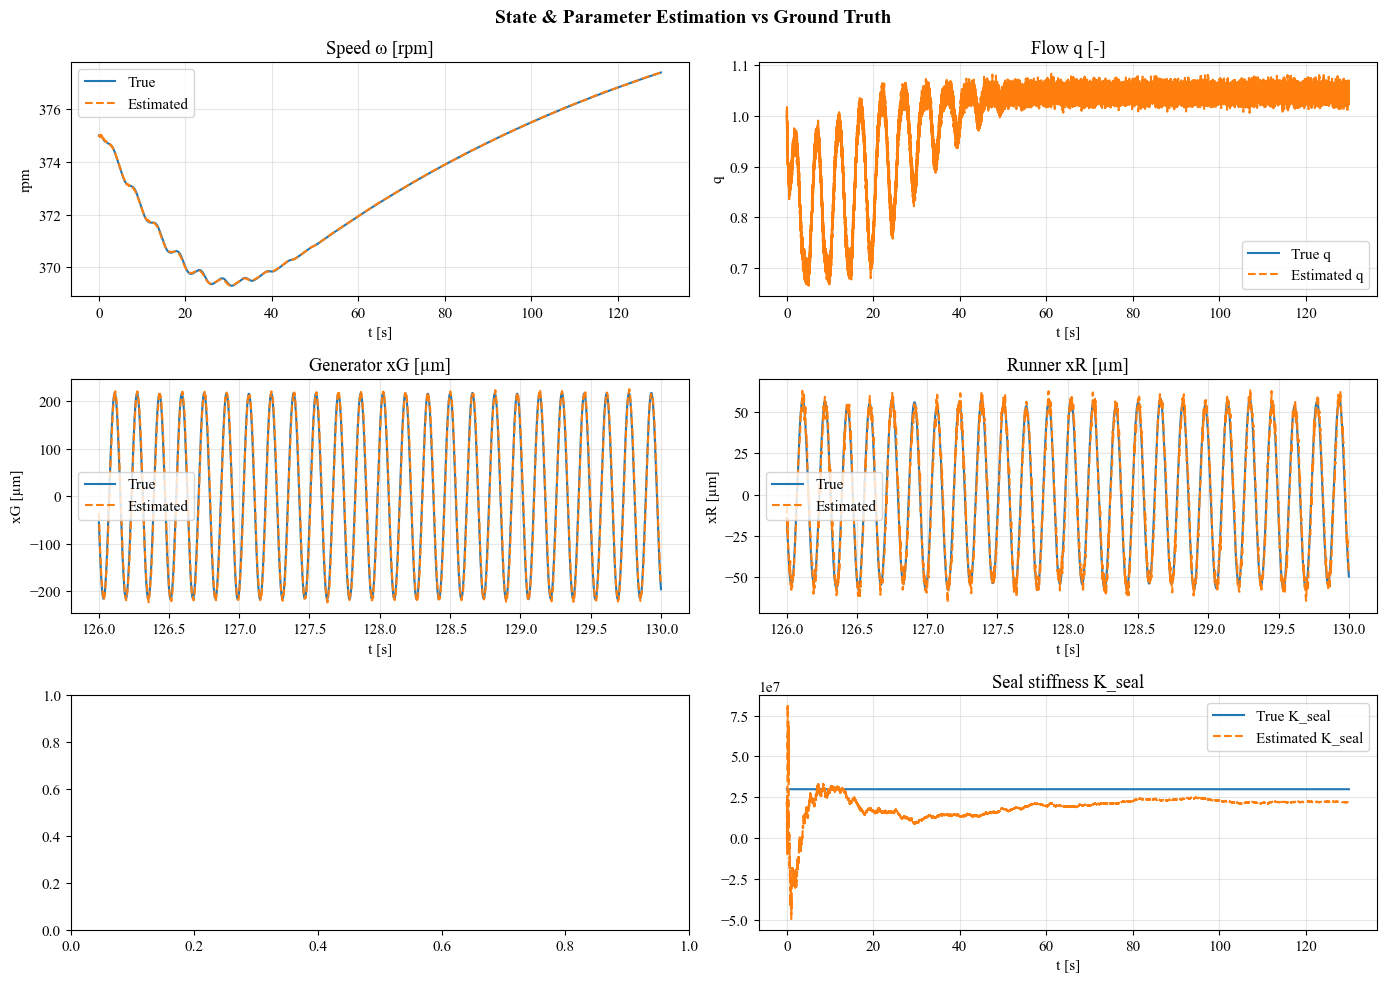

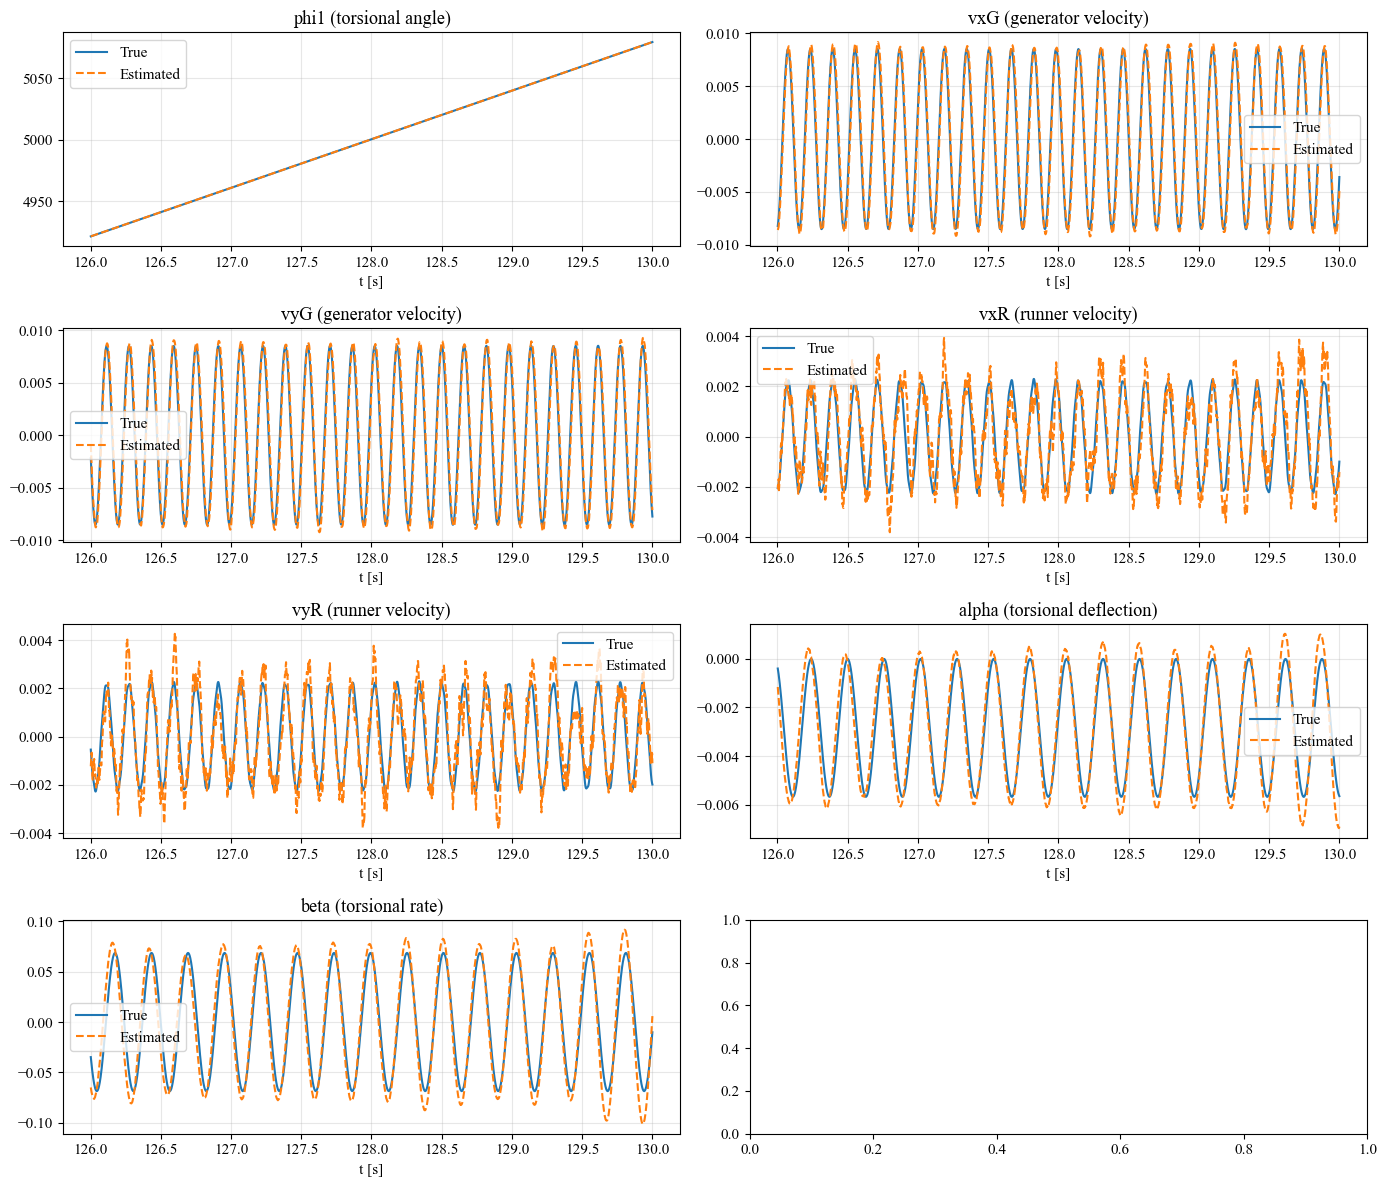

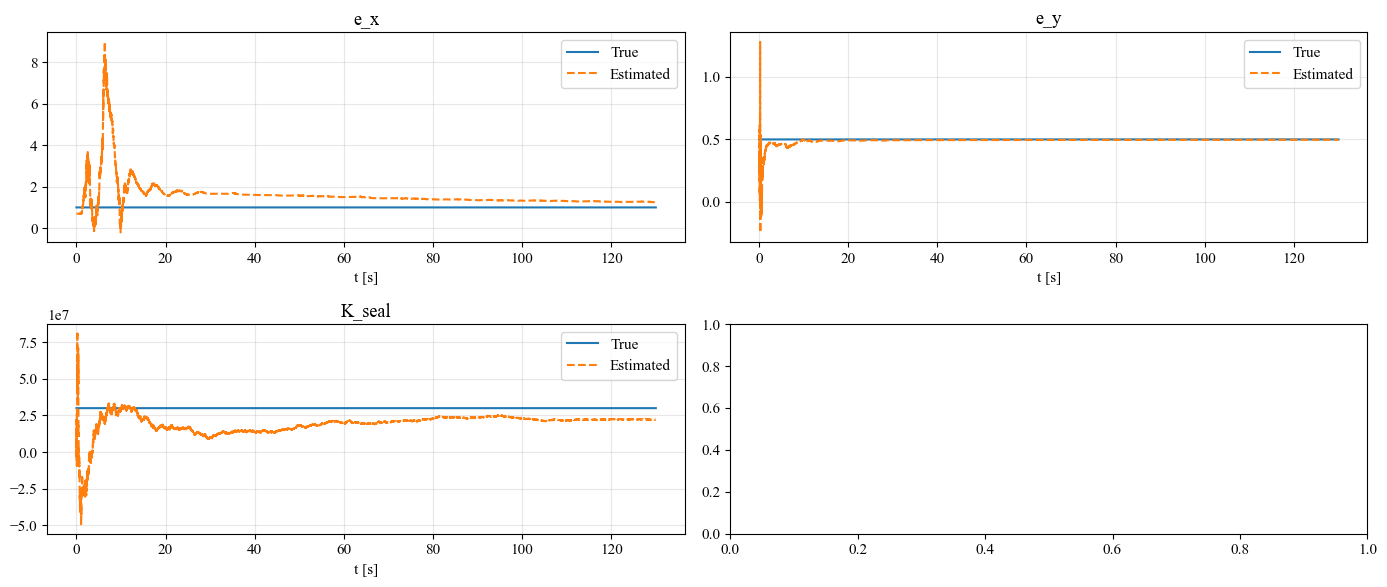

In [13]:
np.random.seed(12345)
res_est = run_multi_module_estimation(t_end=130.0, dt=0.002)
plot_states_and_parameters_separately(res_est)


In [14]:
import numpy as np
import pandas as pd

t      = res_est["t"]
x_true = res_est["x_true"]
x_hyd  = res_est["x_hyd"]
x_rot  = res_est["x_rot"]
x_gen  = res_est["x_gen"]
x_run  = res_est["x_run"]
x_n    = res_est["x_n"]
x_gov  = res_est["x_gov"]
p      = res_est["params"]

# ------------------------------------------------------------
# Build full dataframe once in memory
# ------------------------------------------------------------
data = {
    "t": t,
    "x_n": x_n,
    "x_gov": x_gov,
}

for i in range(x_true.shape[0]):
    data[f"x_true_{i}"] = x_true[i, :]

for i in range(x_hyd.shape[0]):
    data[f"x_hyd_{i}"] = x_hyd[i, :]

for i in range(x_rot.shape[0]):
    data[f"x_rot_{i}"] = x_rot[i, :]

for i in range(x_gen.shape[0]):
    data[f"x_gen_{i}"] = x_gen[i, :]

for i in range(x_run.shape[0]):
    data[f"x_run_{i}"] = x_run[i, :]

for key, val in vars(p).items():
    if np.isscalar(val):
        data[key] = np.full_like(t, val, dtype=float)

df = pd.DataFrame(data)

# ------------------------------------------------------------
# Select the windows used by the figure.
# ------------------------------------------------------------
df_orbit = df[df["t"] >= 129.3].copy()                 # last 0.7 s
df_q     = df[(df["t"] >= 0) & (df["t"] <= 90)].copy().iloc[::20]
df_perf  = df[(df["t"] >= 0) & (df["t"] <= 63)].copy().iloc[::20]
df_kseal = df[(df["t"] >= 0) & (df["t"] <= 30)].copy().iloc[::5]
print("  Turbine_res_est_orbit.csv")
print("  Turbine_res_est_q.csv")
print("  Turbine_res_est_perf.csv")
print("  Turbine_res_est_kseal.csv")

  Turbine_res_est_orbit.csv
  Turbine_res_est_q.csv
  Turbine_res_est_perf.csv
  Turbine_res_est_kseal.csv



State RMSE and NRMSE over orbit window t >= 129.302 s
NRMSE is normalized by the truth range over the same window.
    xG : RMSE = 1.193037e-05, NRMSE = 2.748151e-02
    yG : RMSE = 1.193758e-05, NRMSE = 2.750773e-02
    xR : RMSE = 5.089937e-06, NRMSE = 4.373909e-02
    yR : RMSE = 4.872710e-06, NRMSE = 4.216884e-02
------------------------------------------------------------------------
all states : RMSE = 9.144541e-06, NRMSE = 3.522429e-02
------------------------------------------------------------------------
Parameter RMSE and NRMSE over parameter window t <= 80.000 s
Parameter NRMSE is normalized by the true parameter value.
    Cq : RMSE = 3.056064e-01, NRMSE = 9.999886e-01
   e_x : RMSE = 1.189409e+00, NRMSE = 1.189409e+00
   e_y : RMSE = 4.115181e-02, NRMSE = 8.230362e-02
K_seal : RMSE = 1.576108e+07, NRMSE = 5.253693e-01


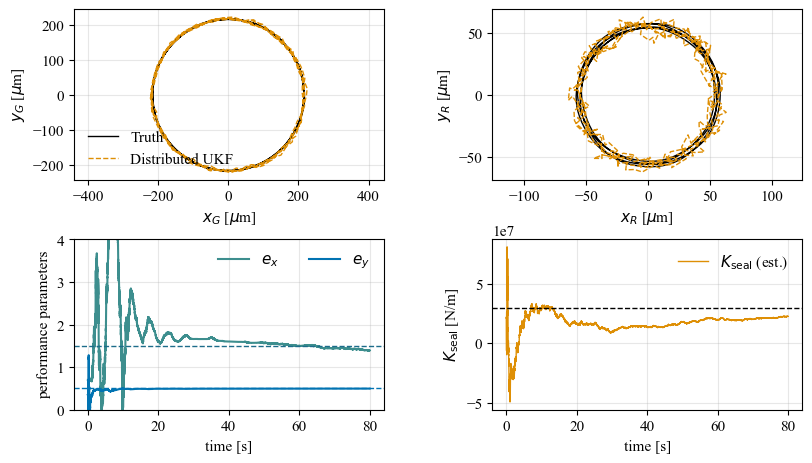

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
import seaborn as sns

# ============================================================
# Extract data from estimation result
# ============================================================
t       = res_est["t"]
x_true  = res_est["x_true"]
x_hyd   = res_est["x_hyd"]
x_rot   = res_est["x_rot"]
x_gen   = res_est["x_gen"]
x_run   = res_est["x_run"]
p       = res_est["params"]

# ============================================================
# Plot style.
# ============================================================
colors  = sns.color_palette("crest", n_colors=8)
colors1 = sns.color_palette("colorblind", n_colors=8)

plt.rc('font', family='Times New Roman', size=11)

# ============================================================
# Time windows
# ============================================================
idx_orbit = t >= (t.max() - 0.7)   # last 10 s
idx_param = t <= 80.0               # first 15 s

# ============================================================
# True vs estimated states
# ============================================================
xG_true, yG_true = x_true[8, :],  x_true[9, :]
xG_est,  yG_est  = x_gen[0, :],   x_gen[1, :]

xR_true, yR_true = x_true[12, :], x_true[13, :]
xR_est,  yR_est  = x_run[0, :],   x_run[1, :]

# ============================================================
# Parameters (physical units)
# ============================================================
Cq_hist = x_hyd[4, :] * p.C_q
ex_hist = x_rot[3, :] * p.e_x
ey_hist = x_rot[4, :] * p.e_y
# eh_hist = x_rot[5, :] * p.e_h
Kseal_hist = x_run[6, :] * p.K_seal
x_hyd_hist = x_hyd[3, :]

Cq_true = p.C_q
ex_true = p.e_x
ey_true = p.e_y
eh_true = p.e_h
Kseal_true = p.K_seal

def rmse(truth, estimate):
    diff = np.asarray(estimate) - np.asarray(truth)
    return np.sqrt(np.mean(diff**2, axis=0))

def nrmse_from_range(truth, estimate):
    truth = np.asarray(truth)
    estimate = np.asarray(estimate)
    denom = np.max(truth, axis=0) - np.min(truth, axis=0)
    denom = np.where(np.abs(denom) > 0.0, denom, 1.0)
    return rmse(truth, estimate) / denom

def nrmse_from_true_value(true_value, estimate):
    scale = abs(float(true_value))
    if scale == 0.0:
        scale = 1.0
    return rmse(np.full_like(np.asarray(estimate), float(true_value), dtype=float), estimate) / scale

state_truth = {
    "xG": xG_true[idx_orbit],
    "yG": yG_true[idx_orbit],
    "xR": xR_true[idx_orbit],
    "yR": yR_true[idx_orbit],
}

state_est = {
    "xG": xG_est[idx_orbit],
    "yG": yG_est[idx_orbit],
    "xR": xR_est[idx_orbit],
    "yR": yR_est[idx_orbit],
}

param_est = {
    "Cq": Cq_hist[idx_param],
    "e_x": ex_hist[idx_param],
    "e_y": ey_hist[idx_param],
    "K_seal": Kseal_hist[idx_param],
}

param_true = {
    "Cq": Cq_true,
    "e_x": ex_true,
    "e_y": ey_true,
    "K_seal": Kseal_true,
}

print("\n" + "=" * 72)
print(f"State RMSE and NRMSE over orbit window t >= {t[idx_orbit][0]:.3f} s")
print("NRMSE is normalized by the truth range over the same window.")
print("=" * 72)
for name in ["xG", "yG", "xR", "yR"]:
    rmse_val = rmse(state_truth[name], state_est[name])
    nrmse_val = nrmse_from_range(state_truth[name], state_est[name])
    print(f"{name:>6} : RMSE = {rmse_val:.6e}, NRMSE = {nrmse_val:.6e}")

state_truth_stack = np.column_stack([state_truth[name] for name in ["xG", "yG", "xR", "yR"]])
state_est_stack = np.column_stack([state_est[name] for name in ["xG", "yG", "xR", "yR"]])
state_rmse_all = np.sqrt(np.mean((state_est_stack - state_truth_stack)**2))
state_nrmse_each = nrmse_from_range(state_truth_stack, state_est_stack)
print("-" * 72)
print(f"all states : RMSE = {state_rmse_all:.6e}, NRMSE = {np.mean(state_nrmse_each):.6e}")

print("-" * 72)
print(f"Parameter RMSE and NRMSE over parameter window t <= {t[idx_param][-1]:.3f} s")
print("Parameter NRMSE is normalized by the true parameter value.")
print("=" * 72)
for name in ["Cq", "e_x", "e_y", "K_seal"]:
    truth_series = np.full_like(np.asarray(param_est[name]), float(param_true[name]), dtype=float)
    rmse_val = rmse(truth_series, param_est[name])
    nrmse_val = nrmse_from_true_value(param_true[name], param_est[name])
    print(f"{name:>6} : RMSE = {rmse_val:.6e}, NRMSE = {nrmse_val:.6e}")
print("=" * 72)

# ============================================================
# Figure layout: 2×2
# ============================================================
fig = plt.figure(figsize=(9.4, 5.2))
gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.35)


# ============================================================
# Row 1 — Generator orbit
# ============================================================
ax00 = plt.subplot(gs[0, 0])
ax00.plot(xG_true[idx_orbit]*1e6, yG_true[idx_orbit]*1e6,
          color='k', lw=1, label='Truth')
ax00.plot(xG_est[idx_orbit]*1e6, yG_est[idx_orbit]*1e6,
          color=colors1[1], lw=1, ls='--', label='Distributed UKF')

ax00.set_xlabel(r'$x_G$ [$\mu$m]')
ax00.set_ylabel(r'$y_G$ [$\mu$m]')
# ax00.set_title('Generator orbit')
ax00.axis('equal')
ax00.grid(alpha=0.3)
ax00.legend(frameon=False, loc='lower left')


# ============================================================
# Row 1 — Runner orbit
# ============================================================
ax01 = plt.subplot(gs[0, 1])
ax01.plot(xR_true[idx_orbit]*1e6, yR_true[idx_orbit]*1e6,
          color='k', lw=1, label='Truth')
ax01.plot(xR_est[idx_orbit]*1e6, yR_est[idx_orbit]*1e6,
          color=colors1[1], lw=1, ls='--', label='Distributed UKF')

ax01.set_xlabel(r'$x_R$ [$\mu$m]')
ax01.set_ylabel(r'$y_R$ [$\mu$m]')
# ax01.set_title('Runner orbit')
ax01.axis('equal')
ax01.grid(alpha=0.3)
# ax01.legend(frameon=False, ncol=2, loc='lower right')

# ============================================================
# Row 2 — Performance parameters
# ============================================================
ax10 = plt.subplot(gs[1, 0])
# ax10.plot(t[idx_param], Cq_hist[idx_param], color=colors1[2], label=r'$C_q$')
ax10.plot(t[idx_param], ex_hist[idx_param], color=colors[3], label=r'$e_x$')
ax10.plot(t[idx_param], ey_hist[idx_param], color=colors1[0], label=r'$e_y$')
# ax10.plot(t[idx_param], eh_hist[idx_param], color=colors[5], label=r'$e_h$')

# ax10.axhline(Cq_true, color=colors1[2], ls='--', lw=1)
# ax10.axhline(ex_true, color=colors[3], ls='--', lw=1)
ax10.axhline(ey_true, color=colors1[0], ls='--', lw=1)
ax10.axhline(eh_true, color=colors[5], ls='--', lw=1)

ax10.set_xlabel('time [s]')
ax10.set_ylabel('performance parameters')
ax10.grid(alpha=0.3)
ax10.legend(frameon=False, ncol=2)
ax10.set_ylim([0,4])

# ============================================================
# Row 2 — Mechanical parameter
# ============================================================
ax11 = plt.subplot(gs[1, 1])
ax11.plot(t[idx_param], Kseal_hist[idx_param],
          color=colors1[1], lw=1,
          label=r'$K_{\mathrm{seal}}$ (est.)')
ax11.axhline(Kseal_true, color='k', ls='--', lw=1)
# ax11.set_ylim([0,4])
ax11.set_xlabel('time [s]')
ax11.set_ylabel(r'$K_{\mathrm{seal}}$ [N/m]')
ax11.grid(alpha=0.3)
ax11.legend(frameon=False)

# ============================================================
# Display figure.
# ============================================================
plt.show()
import os
import numpy as np
import pandas as pd

def build_sos_turbine_summary_tables(res_est):
    """
    Builds the tables used by the 2x2 summary plot:
      - orbit_generator
      - orbit_runner
      - params_performance
      - params_mechanical

    Builds the tables used by the summary plot.
    """
    t      = res_est["t"]
    x_true = res_est["x_true"]
    x_hyd  = res_est["x_hyd"]
    x_rot  = res_est["x_rot"]
    x_gen  = res_est["x_gen"]
    x_run  = res_est["x_run"]
    p      = res_est["params"]

    # Plot windows.
    idx_orbit = t >= (t.max() - 0.7)
    idx_param = t <= 80.0

    # --- Orbits (true vs estimated)
    xG_true, yG_true = x_true[8, :],  x_true[9, :]
    xG_est,  yG_est  = x_gen[0, :],   x_gen[1, :]

    xR_true, yR_true = x_true[12, :], x_true[13, :]
    xR_est,  yR_est  = x_run[0, :],   x_run[1, :]

    df_orb_G = pd.DataFrame({
        "t_s": t[idx_orbit],
        "xG_true_um": xG_true[idx_orbit] * 1e6,
        "yG_true_um": yG_true[idx_orbit] * 1e6,
        "xG_est_um":  xG_est[idx_orbit]  * 1e6,
        "yG_est_um":  yG_est[idx_orbit]  * 1e6,
    })

    df_orb_R = pd.DataFrame({
        "t_s": t[idx_orbit],
        "xR_true_um": xR_true[idx_orbit] * 1e6,
        "yR_true_um": yR_true[idx_orbit] * 1e6,
        "xR_est_um":  xR_est[idx_orbit]  * 1e6,
        "yR_est_um":  yR_est[idx_orbit]  * 1e6,
    })

    # --- Performance parameters (physical units)
    ex_hist = x_rot[3, :] * p.e_x
    ey_hist = x_rot[4, :] * p.e_y
    eh_true = p.e_h
    ey_true = p.e_y

    df_perf = pd.DataFrame({
        "t_s": t[idx_param],
        "e_x_est": ex_hist[idx_param],
        "e_y_est": ey_hist[idx_param],
        "e_y_true_const": np.full(np.count_nonzero(idx_param), ey_true, dtype=float),
        "e_h_true_const": np.full(np.count_nonzero(idx_param), eh_true, dtype=float),
    })

    # --- Mechanical param (physical units)
    Kseal_hist = x_run[6, :] * p.K_seal
    Kseal_true = p.K_seal

    df_mech = pd.DataFrame({
        "t_s": t[idx_param],
        "Kseal_est_N_per_m": Kseal_hist[idx_param],
        "Kseal_true_const_N_per_m": np.full(np.count_nonzero(idx_param), Kseal_true, dtype=float),
    })

    # Summary tables.

    # Additional table outputs are disabled.
# res_est = run_multi_module_estimation(...)
build_sos_turbine_summary_tables(res_est)


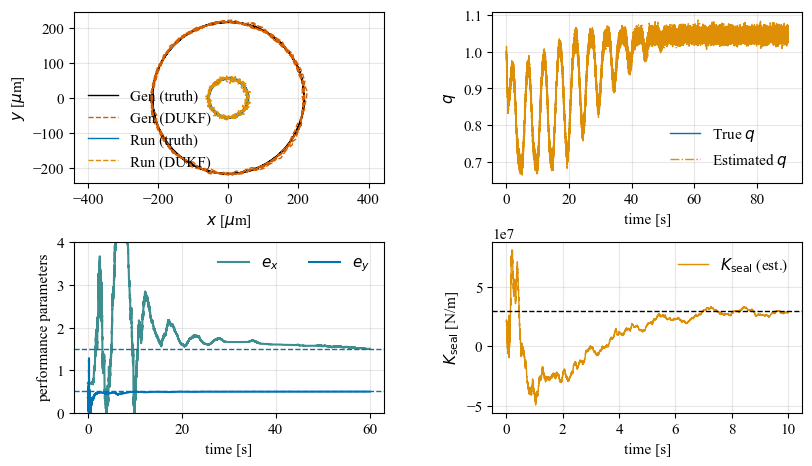

In [16]:
# ============================================================
# Figure layout: 2×2
# ============================================================
fig = plt.figure(figsize=(9.4, 5.2))
gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.35)
idx_param = t <= 90.0              # first 15 s for parameters, last 10 s for orbits
# ============================================================
# Row 1 — Generator + Runner orbits on the same axes
# ============================================================
ax00 = plt.subplot(gs[0, 0])

# Generator orbit
ax00.plot(xG_true[idx_orbit]*1e6, yG_true[idx_orbit]*1e6,
          color='k', lw=1, label='Gen (truth)')
ax00.plot(xG_est[idx_orbit]*1e6, yG_est[idx_orbit]*1e6,
          color=colors1[3], lw=1, ls='--', label='Gen (DUKF)')

# Runner orbit (same axes, different color)
ax00.plot(xR_true[idx_orbit]*1e6, yR_true[idx_orbit]*1e6,
          color=colors1[0], lw=1, label='Run (truth)')
ax00.plot(xR_est[idx_orbit]*1e6, yR_est[idx_orbit]*1e6,
          color=colors1[1], lw=1, ls='--', label='Run (DUKF)')

ax00.set_xlabel(r'$x$ [$\mu$m]')
ax00.set_ylabel(r'$y$ [$\mu$m]')
ax00.axis('equal')
ax00.grid(alpha=0.3)
ax00.legend(frameon=False, loc='lower left')

# ============================================================
# Row 1 — Hydraulic estimated q (replacing runner orbit panel)
# ============================================================
x_n_hist = res_est["x_n"]
est_q_hist=res_est["x_hyd"][3, :]



ax01 = plt.subplot(gs[0, 1])
ax01.plot(t[idx_param], x_true[3,idx_param], color=colors1[0], lw=1, label='True $q$')
ax01.plot(t[idx_param], est_q_hist[idx_param], color=colors1[1], lw=1, ls='-.', label='Estimated $q$')

# ax01.set_title(r'Flow $q$ [-]')
ax01.set_xlabel('time [s]')
ax01.set_ylabel(r'$q$')
ax01.grid(True, alpha=0.3)
ax01.legend(frameon=False)

# ============================================================
# Row 2 — Performance parameters
# ============================================================
idx_param = t <= 60.0 

ax10 = plt.subplot(gs[1, 0])
ax10.plot(t[idx_param], ex_hist[idx_param], color=colors[3], label=r'$e_x$')
ax10.plot(t[idx_param], ey_hist[idx_param], color=colors1[0], label=r'$e_y$')

ax10.axhline(ey_true, color=colors1[0], ls='--', lw=1)
ax10.axhline(eh_true, color=colors[5], ls='--', lw=1)

ax10.set_xlabel('time [s]')
ax10.set_ylabel('performance parameters')
ax10.grid(alpha=0.3)
ax10.legend(frameon=False, ncol=2)
ax10.set_ylim([0, 4])

# ============================================================
# Row 2 — Mechanical parameter
# ============================================================
idx_param = t <= 10.0 
ax11 = plt.subplot(gs[1, 1])
ax11.plot(t[idx_param], Kseal_hist[idx_param],
          color=colors1[1], lw=1,
          label=r'$K_{\mathrm{seal}}$ (est.)')
ax11.axhline(Kseal_true, color='k', ls='--', lw=1)
ax11.set_xlabel('time [s]')
ax11.set_ylabel(r'$K_{\mathrm{seal}}$ [N/m]')
ax11.grid(alpha=0.3)
ax11.legend(frameon=False)
# ax11.set_ylim([0, 10e7])
plt.show()
